# Commercial Property Price Prediction

# 1. Importing Required Libraries

this section imports the Python libraries required for data preprocessing, exploratory data analysis, visualization, feature engineering, model development, and evaluation.

In [1]:
import sys
from pathlib import Path

import setuptools

# Yellowbrick still imports distutils on Python 3.12+; this compatibility shim keeps
# the notebook runnable in modern Python environments without changing the model workflow.
import setuptools._distutils as distutils
sys.modules.setdefault("distutils", distutils)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from yellowbrick.regressor import PredictionError, ResidualsPlot
from yellowbrick.model_selection import FeatureImportances

# 2. Loading and Exploring the Dataset

## 2.1 Loading the Dataset

The commercial property dataset was loaded into the notebook using the Pandas library. The first few rows were examined to verify that the dataset was imported correctly.

In [2]:
# Resolve the dataset path robustly whether the notebook is opened from the repo root
# or from the notebook folder itself.
project_root = Path.cwd()
search_roots = [
    project_root,
    project_root / "notebook",
    project_root.parent,
]

csv_path = None
for base in search_roots:
    candidate = base / "data" / "sample_data.csv"
    if candidate.exists():
        csv_path = candidate
        break

if csv_path is None:
    raise FileNotFoundError("sample_data.csv could not be found in the expected project locations.")

df = pd.read_csv(csv_path, low_memory=False)

In [3]:
df.head()

,listingId,realtyNo,realtyId,advertiseOwnerName,mainCategoryName,categories,subCategoryName,mainCategoryId,categoryId,cityId,...,buildStateName,furnished,sideName,fuelName,heatingName,heatingId,amount,currencycode,creditName,productIds
0,SAMPLE-000001,35517,10000000,Emlakçıdan,İşyeri,İşyeri Satılık,Dükkan & Mağaza,1000020000,1000010000,21,...,İkinci El,False,NaN,NaN,Merkezi,101301.0,0.0,NaN,Uygun,NaN
1,SAMPLE-000002,32443,10000001,Emlakçıdan,İşyeri,İşyeri Satılık,Dükkan & Mağaza,1000020000,1000010000,61,...,NaN,False,NaN,Elektrik,Yok,101305.0,0.0,NaN,Bilinmiyor,NaN
2,SAMPLE-000003,148210,10000002,Emlakçıdan,İşyeri,İşyeri Satılık,Dükkan & Mağaza,1000020000,1000010000,42,...,Sıfır,False,NaN,Diğer,Kombi,101309.0,0.0,NaN,Uygun,NaN
3,SAMPLE-000004,46551,10000003,Emlakçıdan,İşyeri,İşyeri Satılık,Depo & Antrepo,1000020000,1000010000,34,...,İkinci El,False,NaN,Elektrik,Yok,101313.0,0.0,NaN,Uygun,NaN
4,SAMPLE-000005,148738,10000004,Emlakçıdan,İşyeri,İşyeri Satılık,Cafe & Bar,1000020000,1000010000,26,...,NaN,False,NaN,Yok,Klima,NaN,0.0,NaN,Uygun,NaN


## 2.2 General Information

In [4]:
df.shape

(8688, 66)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8688 entries, 0 to 8687
Data columns (total 66 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   listingId                         8688 non-null   str    
 1   realtyNo                          8688 non-null   int64  
 2   realtyId                          8688 non-null   int64  
 3   advertiseOwnerName                8688 non-null   str    
 4   mainCategoryName                  8688 non-null   str    
 5   categories                        8688 non-null   str    
 6   subCategoryName                   8688 non-null   str    
 7   mainCategoryId                    8688 non-null   int64  
 8   categoryId                        8688 non-null   int64  
 9   cityId                            8688 non-null   int64  
 10  cityName                          8688 non-null   str    
 11  countyId                          8688 non-null   int64  
 12  countyName       

In [6]:
df.describe()

,realtyNo,realtyId,mainCategoryId,categoryId,cityId,countyId,districtId,age,sqm,floorId,...,realtyPriceTl,realtyPriceCurrencyId,firmUserId,firmId,productCount,firmSummaryPackageCategoryTypeId,buildStateId,heatingId,amount,productIds
count,8688.000000,8.688000e+03,8.688000e+03,8.688000e+03,8688.000000,8688.000000,8688.000000,7418.000000,8688.000000,7116.000000,...,8.688000e+03,8688.0,8688.000000,8029.000000,8688.000000,8688.000000,5612.000000,7245.000000,8688.0,0.0
mean,74892.221225,1.000434e+07,1.000020e+09,1.000010e+09,43.026819,1610.837017,85764.673688,10.757077,157.938651,101205.497611,...,6.381499e+06,1.0,5007.742518,4499.793000,0.023596,91314.273366,101603.953849,101307.581643,0.0,NaN
std,43316.715138,2.508154e+03,0.000000e+00,0.000000e+00,24.929224,298.346263,43912.046264,8.928236,136.710702,3.478777,...,7.693798e+06,0.0,1731.927567,1449.993728,0.176351,52332.159828,2.598927,4.676341,0.0,NaN
min,103.000000,1.000000e+07,1.000020e+09,1.000010e+09,1.000000,1100.000000,10014.000000,0.000000,20.000000,101200.000000,...,5.000000e+05,1.0,2000.000000,2000.000000,0.000000,9.000000,101600.000000,101300.000000,0.0,NaN
25%,37099.500000,1.000217e+07,1.000020e+09,1.000010e+09,21.000000,1348.000000,48035.500000,1.000000,73.000000,101202.000000,...,2.210000e+06,1.0,3506.000000,3243.000000,0.000000,46119.750000,101602.000000,101303.000000,0.0,NaN
50%,75354.500000,1.000434e+07,1.000020e+09,1.000010e+09,41.000000,1611.000000,84809.000000,10.000000,119.000000,101206.000000,...,4.080000e+06,1.0,5025.500000,4491.000000,0.000000,92146.500000,101604.000000,101308.000000,0.0,NaN
75%,112079.000000,1.000652e+07,1.000020e+09,1.000010e+09,63.000000,1867.000000,123441.250000,20.000000,195.000000,101208.000000,...,7.630000e+06,1.0,6516.500000,5773.000000,0.000000,135700.500000,101606.000000,101312.000000,0.0,NaN
max,149966.000000,1.000869e+07,1.000020e+09,1.000010e+09,90.000000,2130.000000,161997.000000,25.000000,1840.000000,101211.000000,...,1.316100e+08,1.0,7999.000000,6999.000000,2.000000,181302.000000,101608.000000,101315.000000,0.0,NaN


## 2.3 Missing Value Analysis

In [7]:
df.isnull().sum().sort_values(ascending=False)

productIds         8688
sideName           8609
currencycode       6980
fuelName           4219
floorCount         3675
                   ... 
breadcrumbs4Url       0
breadcrumbs3Url       0
imageUrl              0
images                0
imageCount            0
Length: 66, dtype: int64

Missing values were examined to identify features with high proportions of missing data. Before model development, these features would either be removed or handled using appropriate imputation techniques.

The objective of this project is to predict commercial property sale prices. Therefore, realtyPriceTl was selected as the target variable because it represents standardized property prices in Turkish Lira (TL), ensuring consistent model training and evaluation.

In [8]:
df["realtyPriceTl"].describe()

count    8.688000e+03
mean     6.381499e+06
std      7.693798e+06
min      5.000000e+05
25%      2.210000e+06
50%      4.080000e+06
75%      7.630000e+06
max      1.316100e+08
Name: realtyPriceTl, dtype: float64

The minimum value of realtyPriceTl is 1 TL, which appears unrealistic and may indicate a data entry error. This observation will be further investigated during the outlier analysis before model development.

In [9]:
missing = df.isnull().sum().sort_values(ascending=False)
missing.head(20)

productIds          8688
sideName            8609
currencycode        6980
fuelName            4219
floorCount          3675
buildStateName      3206
buildStateId        3076
firmUserPhoto       2709
floorName           1576
floorId             1572
heatingName         1494
heatingId           1443
age                 1270
firmLogo            1156
firmId               659
featuringProduct       0
firmUserId             0
startDate              0
endDate                0
realtyPrice            0
dtype: int64

The number and percentage of missing values were calculated for each feature to evaluate data quality and determine the appropriate preprocessing strategy.

In [10]:
missing_percent = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_percent.head(20)

productIds          100.000000
sideName             99.090700
currencycode         80.340700
fuelName             48.561234
floorCount           42.299724
buildStateName       36.901473
buildStateId         35.405157
firmUserPhoto        31.180939
floorName            18.139963
floorId              18.093923
heatingName          17.196133
heatingId            16.609116
age                  14.617864
firmLogo             13.305709
firmId                7.585175
featuringProduct      0.000000
firmUserId            0.000000
startDate             0.000000
endDate               0.000000
realtyPrice           0.000000
dtype: float64

The featuringProduct, sideName, and productIds features contain more than 99% missing values. Since these variables provide limited analytical value, they will be removed during the data cleaning stage.


The currencyCode feature contains approximately 80% missing values and will be evaluated separately during preprocessing.

The fuelName, floorCount, buildStateName, and buildStateId features contain between 35% and 50% missing values. These variables will be examined individually before deciding whether to retain, remove, or impute them.

Features such as age, floorName, floorId, heatingName, and heatingId contain approximately 15–18% missing values and may be handled using appropriate imputation techniques.

The imageUrl and images features contain only about 1.3% missing values.

# 3. Data Preprocessing

## 3.1 Removing Unnecessary Features

Features that were considered irrelevant for price prediction, contained identifying information, URLs, image references, or excessive missing values were removed from the dataset. Although property images were not used in this project, the imageCount feature was retained because it may still provide useful information about the listings.

In [11]:
df.columns

Index(['listingId', 'realtyNo', 'realtyId', 'advertiseOwnerName',
       'mainCategoryName', 'categories', 'subCategoryName', 'mainCategoryId',
       'categoryId', 'cityId', 'cityName', 'countyId', 'countyName',
       'areaName', 'areaId', 'districtId', 'districtName', 'title', 'age',
       'roomAndLivingRoom', 'sqm', 'floorName', 'floorId', 'bathRoom',
       'livingRoom', 'room', 'floorCount', 'mapLatLon', 'detailUrl',
       'breadcrumbs4Url', 'breadcrumbs3Url', 'imageUrl', 'images',
       'imageCount', 'description', 'createdDate', 'updatedDate', 'startDate',
       'endDate', 'realtyPrice', 'realtyPriceCurrencyCode', 'realtyPriceTl',
       'realtyPriceCurrencyId', 'showPrice', 'firmUserId', 'firmUserFirstName',
       'firmUserLastName', 'firmUserPhoto', 'firmId', 'firmLogo',
       'firmUserFullName', 'productCount', 'featuringProduct', 'superRealty',
       'firmSummaryPackageCategoryTypeId', 'buildStateId', 'buildStateName',
       'furnished', 'sideName', 'fuelName', 'hea

In [12]:
df["advertiseOwnerName"].value_counts()

advertiseOwnerName
Emlakçıdan      7713
Sahibinden       546
Müteahhitten     175
Firma            175
Bankadan          79
Name: count, dtype: int64

In [13]:
drop_columns = ['listingId', 'detailUrl', 'breadcrumbs4Url', 'breadcrumbs3Url', 'imageUrl', 'images',
                 'firmUserFirstName', 'firmUserLastName', 'firmUserPhoto', 'firmLogo', 'firmUserFullName',
                 'sideName', 'featuringProduct', 'productIds']

In [14]:
df = df.drop(columns=drop_columns)

In [15]:
df.shape

(8688, 52)

After removing unnecessary features, the dataset was reduced from 66 to 52 variables. This simplification improves data quality and prepares the dataset for subsequent preprocessing and modeling stages.

## 3.2 Data Type Standardization


The age feature contained both integer and decimal representations of the same building ages (e.g., 126 and 126.0). These values were standardized to ensure data consistency.

In [16]:
df["age"].unique()

array([nan, 20., 10.,  0.,  1., 25., 15.,  5.])

The age feature stored identical building ages using different numeric formats. During the inspection, one record was also found to have a missing value that caused a column shift. This record was corrected, and the feature was converted into a consistent numeric format.

In [17]:
integer_columns = [
    "age",
    "bathRoom",
    "livingRoom",
    "room",
    "floorCount",
    "imageCount",
    "realtyPriceCurrencyId"
]

float_columns = [
    "sqm",
    "floorId",
    "realtyPrice",
    "realtyPriceTl",
    "productCount",
    "firmSummaryPackageCategoryTypeId",
    "buildStateId",
    "heatingId",
    "amount"
]

for col in integer_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")

for col in float_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [18]:
df["age"].describe()

count       7418.0
mean     10.757077
std       8.928236
min            0.0
25%            1.0
50%           10.0
75%           20.0
max           25.0
Name: age, dtype: Float64

In [19]:
df["age"].sort_values(ascending=False).head(10)

2136    25
3258    25
5714    25
5715    25
5725    25
5745    25
5749    25
5751    25
5758    25
5764    25
Name: age, dtype: Int64

Records with unusually high building ages were reviewed together with their titles and descriptions. Although some values appeared suspicious, no definitive evidence of data entry errors was found; therefore, these observations were retained.

In [20]:
df[(df["age"] == 190) |
   (df["age"] == 850) |
   (df["age"] == 560) |
   (df["age"] == 201) 
   ][["subCategoryName",
       "mainCategoryName", "categories", "age","title","description"]]

,subCategoryName,mainCategoryName,categories,age,title,description


The floorName feature was examined to standardize floor-level information. The values "Kot 1", "Kot 2", and "Kot 3" were converted to -1, -2, and -3, respectively. Other descriptive floor labels were preserved because they provide meaningful information.

In [21]:
df["floorName"].value_counts(dropna=False)

floorName
NaN             1576
7. Kat           624
Zemin            620
5. Kat           606
6. Kat           600
Yüksek giriş     599
1. Kat           598
9. Kat           593
10. Kat          586
8. Kat           576
4. Kat           574
2. Kat           570
3. Kat           566
Name: count, dtype: int64

In [22]:
replace_dict = {
    "Kot 1": "-1",
    "Kot 2": "-2",
    "Kot 3": "-3"
}

df["floorName"] = df["floorName"].replace(replace_dict)

The floorCount feature was converted to a numeric format, and its distribution, descriptive statistics, and missing values were examined.

In [23]:
df["floorCount"].value_counts(dropna=False)

floorCount
<NA>    3675
7        656
2        645
8        642
3        626
10       623
4        609
5        608
6        604
Name: count, dtype: Int64

The floorCount feature contains 3,665 missing values. Since removing these records would result in substantial data loss, the missing values were retained for later handling.

In [24]:
df["floorCount"].isnull().sum()

np.int64(3675)

In [25]:
df["floorCount"].describe()

count      5013.0
mean     5.630561
std      2.507204
min           2.0
25%           3.0
50%           6.0
75%           8.0
max          10.0
Name: floorCount, dtype: Float64

In [26]:
df["floorCount"].sort_values(ascending=False).head(20)

0       10
5369    10
896     10
897     10
899     10
7893    10
3252    10
7892    10
2069    10
4139    10
6188    10
7874    10
3267    10
920     10
922     10
6174    10
5408    10
2053    10
4116    10
4114    10
Name: floorCount, dtype: Int64

Listings with unusually high numbers of floors were reviewed using their titles and descriptions. The inspection indicated that these values were consistent with the property information and were therefore retained.

Properties with exceptionally large floor areas were examined. Most of these listings corresponded to large commercial properties such as factories, farms, or fuel stations, indicating that these values were realistic rather than erroneous.

In [27]:
df["sqm"].describe()

count    8688.000000
mean      157.938651
std       136.710702
min        20.000000
25%        73.000000
50%       119.000000
75%       195.000000
max      1840.000000
Name: sqm, dtype: float64

Listings with very small floor areas were also reviewed to identify potential data entry errors.

In [28]:
df["sqm"].sort_values().head(20)

6532    20.0
2842    20.0
1435    20.0
1437    20.0
1063    20.0
4629    20.0
2879    20.0
2740    20.0
4613    20.0
1464    20.0
6379    20.0
3044    20.0
4217    20.0
878     20.0
6236    20.0
2129    20.0
2181    20.0
6646    20.0
7745    20.0
5450    20.0
Name: sqm, dtype: float64

Records with a floor area of 0 m² were manually reviewed. For one listing, the property description explicitly stated that the total area was 10,800 m². Therefore, the floor area was corrected to 10,800 instead of treating it as missing.

In [29]:
df.loc[5408, "sqm"] = 10800

In [30]:
df.loc[5408, ["subCategoryName", "sqm", "title"]]

subCategoryName            İş Hanı
sqm                        10800.0
title              SATILIK İŞ HANI
Name: 5408, dtype: object

realtyPriceTl

In [31]:
df["realtyPriceTl"].describe()

count    8.688000e+03
mean     6.381499e+06
std      7.693798e+06
min      5.000000e+05
25%      2.210000e+06
50%      4.080000e+06
75%      7.630000e+06
max      1.316100e+08
Name: realtyPriceTl, dtype: float64

In [32]:
df["realtyPriceTl"].sort_values().head()

3150    500000
1773    500000
1808    500000
5487    500000
8022    500000
Name: realtyPriceTl, dtype: int64

In [33]:
df["realtyPriceTl"].sort_values(ascending=False).head()

3965    131610000
1883    129510000
913      85580000
4028     82340000
476      80110000
Name: realtyPriceTl, dtype: int64

The minimum and maximum values of the realtyPriceTl variable were examined. The record with the minimum price had already been corrected during the previous data alignment process. Extremely high prices were found to belong to large-scale commercial properties and were therefore retained.

creditName

In [34]:
df["creditName"].value_counts(dropna=False)

creditName
Uygun                6971
Bilinmiyor            758
Uygun Değil           713
Değerlendiriliyor     246
Name: count, dtype: int64

The categories in the creditName column were examined. A single record contained the value "Fourlex", which was inconsistent with the purpose of this variable. The property description indicated that the building consisted of three floors, and no information related to credit eligibility was found. Since this value was considered a data entry error, it was replaced with a missing value (NaN).

In [35]:
df["creditName"].value_counts(dropna=False)

creditName
Uygun                6971
Bilinmiyor            758
Uygun Değil           713
Değerlendiriliyor     246
Name: count, dtype: int64

heatingName

In [36]:
df["heatingName"].value_counts(dropna=False)

heatingName
NaN              1494
Klima            1253
Yerden Isıtma    1215
Soba             1208
Yok              1176
Merkezi          1171
Kombi            1171
Name: count, dtype: int64

The categories in the heatingName column were reviewed. No clear inconsistencies or data quality issues were identified; therefore, no modifications were applied.

buildStateName

In [37]:
df["buildStateName"].value_counts(dropna=False)

buildStateName
İkinci El           4136
NaN                 3206
Sıfır                759
Yapım Aşamasında     295
Proje                292
Name: count, dtype: int64

The buildStateName column contains the categories Second Hand, Zero, and Under Construction, together with missing values. Since no obvious data inconsistencies were detected, the column was left unchanged.

furnished

In [38]:
df["furnished"].value_counts(dropna=False)

furnished
False    8342
True      346
Name: count, dtype: int64

One record stored the value "false" as a lowercase string instead of a Boolean value. To ensure consistency, this value was standardized to the Boolean value False.

In [39]:
df["furnished"].value_counts(dropna=False)

furnished
False    8342
True      346
Name: count, dtype: int64

In [40]:
df["furnished"] = (
    df["furnished"]
    .astype("string")
    .str.strip()
    .str.lower()
    .replace({
        "true": 1,
        "false": 0,
        "1": 1,
        "0": 0
    })
)

df["furnished"] = pd.to_numeric(
    df["furnished"],
    errors="coerce"
).astype("Int64")

In [41]:
print(df["furnished"].dtype)
print(df["furnished"].value_counts(dropna=False))

Int64
furnished
0    8342
1     346
Name: count, dtype: Int64


currencycode

The currencyCode column was examined and found to contain only TL and missing values. Since no data inconsistency was detected, no modification was applied.

In [42]:
df["currencycode"].value_counts(dropna=False)

currencycode
NaN    6980
TL     1708
Name: count, dtype: int64

roomAndLivingRoom

In [43]:
df["roomAndLivingRoom"].value_counts(dropna=False)

roomAndLivingRoom
Stüdyo    2637
2+1       1218
1+1       1188
1+0        912
3+1        820
2+0        693
4+1        543
5+1        339
6+1        338
Name: count, dtype: int64

The values in the roomAndLivingRoom column were reviewed. Since the values consistently represented room layouts (e.g., 2+1, 3+1) and no obvious inconsistencies were observed, the column was kept unchanged.

room

In [44]:
df["room"].value_counts(dropna=False).sort_index()

room
0    2637
1    2100
2    1911
3     820
4     543
5     339
6     338
Name: count, dtype: Int64

In [45]:
invalid_room_indices = [445, 1634, 3050, 5987, 6478]

df.loc[invalid_room_indices, "room"] = pd.NA
df["room"] = df["room"].astype("Int64")

In [46]:
df.loc[invalid_room_indices, [
    "room",
    "roomAndLivingRoom",
    "sqm",
    "subCategoryName",
    "title"
]]

,room,roomAndLivingRoom,sqm,subCategoryName,title
445,<NA>,3+1,32.0,Dükkan & Mağaza,SATILIK DÜKKAN & MAĞAZA
1634,<NA>,2+1,121.0,Dükkan & Mağaza,SATILIK DÜKKAN & MAĞAZA
3050,<NA>,2+0,178.0,Cafe & Bar,SATILIK CAFE & BAR
5987,<NA>,2+1,156.0,Dükkan & Mağaza,SATILIK DÜKKAN & MAĞAZA
6478,<NA>,2+1,62.0,Dükkan & Mağaza,SATILIK DÜKKAN & MAĞAZA


Values greater than 50 in the room column were manually reviewed together with the listing titles and descriptions. It was observed that these values most likely represented property size, bed capacity, or the number of independent units rather than actual room counts. Since the correct room counts could not be determined reliably, these records were marked as missing values (NaN).

livingRoom

Most observations in the livingRoom column contained the value 0, while the remaining records contained either 1 or 2, which were consistent with the corresponding roomAndLivingRoom values. Therefore, no modification was required.

In [47]:
df["livingRoom"].value_counts(dropna=False)

livingRoom
0    8517
1     171
Name: count, dtype: Int64

Final Validation of Numerical Variables

In [48]:
numeric_cols = [
    "sqm",
    "floorCount",
    "room",
    "bathRoom",
    "livingRoom",
    "age"
]

df[numeric_cols].describe()

,sqm,floorCount,room,bathRoom,livingRoom,age
count,8688.000000,5013.0,8683.0,8688.0,8688.0,7418.0
mean,159.141459,5.630561,1.642981,0.0,0.019682,10.757077
std,178.104587,2.507204,1.627314,0.0,0.138914,8.928236
min,20.000000,2.0,0.0,0.0,0.0,0.0
25%,73.000000,3.0,0.0,0.0,0.0,1.0
50%,119.000000,6.0,1.0,0.0,0.0,10.0
75%,195.000000,8.0,2.0,0.0,0.0,20.0
max,10800.000000,10.0,6.0,0.0,1.0,25.0


Summary statistics of the numerical variables were recalculated after the data cleaning process. The updated distributions confirmed that the inconsistencies in the room variable had been resolved, while no additional issues requiring intervention were identified in the remaining numerical variables.

In [49]:
df.shape

(8688, 52)

In [50]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8688 entries, 0 to 8687
Data columns (total 52 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   realtyNo                          8688 non-null   int64  
 1   realtyId                          8688 non-null   int64  
 2   advertiseOwnerName                8688 non-null   str    
 3   mainCategoryName                  8688 non-null   str    
 4   categories                        8688 non-null   str    
 5   subCategoryName                   8688 non-null   str    
 6   mainCategoryId                    8688 non-null   int64  
 7   categoryId                        8688 non-null   int64  
 8   cityId                            8688 non-null   int64  
 9   cityName                          8688 non-null   str    
 10  countyId                          8688 non-null   int64  
 11  countyName                        8688 non-null   str    
 12  areaName         

In [51]:
df.isnull().sum().sort_values(ascending=False)

currencycode                        6980
fuelName                            4219
floorCount                          3675
buildStateName                      3206
buildStateId                        3076
floorName                           1576
floorId                             1572
heatingName                         1494
heatingId                           1443
age                                 1270
firmId                               659
room                                   5
endDate                                0
realtyPrice                            0
realtyPriceTl                          0
startDate                              0
realtyPriceCurrencyCode                0
realtyNo                               0
firmUserId                             0
realtyPriceCurrencyId                  0
showPrice                              0
createdDate                            0
productCount                           0
superRealty                            0
firmSummaryPacka

In [52]:
df.duplicated().sum()

np.int64(0)

## 3.3 Missing Value Analysis
Missing values were examined in detail by reviewing the corresponding listing titles and descriptions. The investigation indicated that most missing values resulted from unavailable listing information rather than data corruption or column misalignment. Therefore, no imputation was performed at this stage.

floorCount

The floorCount column contains 3,665 missing values. Manual inspection showed that these records generally lacked floor information in the original listings rather than resulting from data errors. Consequently, the missing values were preserved.

In [53]:
df["floorCount"].value_counts(dropna=False).sort_index()

floorCount
2        645
3        626
4        609
5        608
6        604
7        656
8        642
10       623
<NA>    3675
Name: count, dtype: Int64

In [54]:
df[df["floorCount"].isna()][
    ["subCategoryName","title","description","floorCount"]
].head(10)

,subCategoryName,title,description,floorCount
3,Depo & Antrepo,SATILIK DEPO & ANTREPO,Merkezi konumda satılık ticari gayrimenkul.,<NA>
6,Dükkan & Mağaza,SATILIK DÜKKAN & MAĞAZA,Ulaşımı kolay ve merkezi konumda.,<NA>
7,Dükkan & Mağaza,SATILIK DÜKKAN & MAĞAZA,Yatırıma uygun işyeri.,<NA>
11,Otel,SATILIK OTEL,Detaylar için ilan sahibi ile iletişime geçiniz.,<NA>
12,Dükkan & Mağaza,SATILIK DÜKKAN & MAĞAZA,Yatırıma uygun işyeri.,<NA>
15,Plaza Katı,SATILIK PLAZA KATI,Detaylı bilgi için iletişime geçebilirsiniz.,<NA>
20,Dükkan & Mağaza,SATILIK DÜKKAN & MAĞAZA,Yatırıma uygun işyeri.,<NA>
22,Dükkan & Mağaza,SATILIK DÜKKAN & MAĞAZA,Ulaşımı kolay ve merkezi konumda.,<NA>
23,Büro,SATILIK BÜRO,Merkezi konumda satılık ticari gayrimenkul.,<NA>
31,Dükkan & Mağaza,SATILIK DÜKKAN & MAĞAZA,Yatırıma uygun işyeri.,<NA>


buildStateName

Missing values in the buildStateName column were manually reviewed using the listing titles and descriptions. No reliable information was found to infer the building condition; therefore, these values were left unchanged.

In [55]:
df["buildStateName"].value_counts(dropna=False)

buildStateName
İkinci El           4136
NaN                 3206
Sıfır                759
Yapım Aşamasında     295
Proje                292
Name: count, dtype: int64

In [56]:
df[df["buildStateName"].isna()][
    ["subCategoryName","title","description"]
].head(10)

,subCategoryName,title,description
1,Dükkan & Mağaza,SATILIK DÜKKAN & MAĞAZA,Detaylar için ilan sahibi ile iletişime geçiniz.
4,Cafe & Bar,SATILIK CAFE & BAR,Ulaşımı kolay ve merkezi konumda.
10,Dükkan & Mağaza,SATILIK DÜKKAN & MAĞAZA,Detaylar için ilan sahibi ile iletişime geçiniz.
18,Dükkan & Mağaza,SATILIK DÜKKAN & MAĞAZA,Merkezi konumda satılık ticari gayrimenkul.
23,Büro,SATILIK BÜRO,Merkezi konumda satılık ticari gayrimenkul.
24,Büro,SATILIK BÜRO,Detaylı bilgi için iletişime geçebilirsiniz.
25,Dükkan & Mağaza,SATILIK DÜKKAN & MAĞAZA,Yatırıma uygun işyeri.
26,Apartman,SATILIK APARTMAN,Ulaşımı kolay ve merkezi konumda.
31,Dükkan & Mağaza,SATILIK DÜKKAN & MAĞAZA,Yatırıma uygun işyeri.
34,Dükkan & Mağaza,SATILIK DÜKKAN & MAĞAZA,Merkezi konumda satılık ticari gayrimenkul.


buildStateId

The buildStateId column contains 3,032 missing values and 226 records with the value 0. Manual inspection showed that records with the value 0 corresponded to missing building status information rather than a valid category. Since no reliable replacement could be determined, these records were retained.

In [57]:
df["buildStateId"].value_counts(dropna=False)

buildStateId
NaN         3076
101601.0     659
101600.0     648
101603.0     636
101607.0     631
101606.0     617
101604.0     614
101608.0     613
101602.0     609
101605.0     585
Name: count, dtype: int64

In [58]:
df[df["buildStateId"].isna()][
    ["subCategoryName", "title", "description"]
].head(10)

,subCategoryName,title,description
3,Depo & Antrepo,SATILIK DEPO & ANTREPO,Merkezi konumda satılık ticari gayrimenkul.
4,Cafe & Bar,SATILIK CAFE & BAR,Ulaşımı kolay ve merkezi konumda.
7,Dükkan & Mağaza,SATILIK DÜKKAN & MAĞAZA,Yatırıma uygun işyeri.
8,Dükkan & Mağaza,SATILIK DÜKKAN & MAĞAZA,Detaylar için ilan sahibi ile iletişime geçiniz.
12,Dükkan & Mağaza,SATILIK DÜKKAN & MAĞAZA,Yatırıma uygun işyeri.
13,İş Hanı,SATILIK İŞ HANI,Yatırıma uygun işyeri.
23,Büro,SATILIK BÜRO,Merkezi konumda satılık ticari gayrimenkul.
24,Büro,SATILIK BÜRO,Detaylı bilgi için iletişime geçebilirsiniz.
31,Dükkan & Mağaza,SATILIK DÜKKAN & MAĞAZA,Yatırıma uygun işyeri.
39,Dükkan & Mağaza,SATILIK DÜKKAN & MAĞAZA,Yatırıma uygun işyeri.


floorName - floorId

The floorName and floorId columns were evaluated together. The floorName column contains 1,574 missing values, while some records have floorId = 0. Since all records with floorId = 0 also had missing floorName values, the value 0 was interpreted as representing missing information. No transformation was applied.

In [59]:
df["floorName"].value_counts(dropna=False)

floorName
NaN             1576
7. Kat           624
Zemin            620
5. Kat           606
6. Kat           600
Yüksek giriş     599
1. Kat           598
9. Kat           593
10. Kat          586
8. Kat           576
4. Kat           574
2. Kat           570
3. Kat           566
Name: count, dtype: int64

In [60]:
df[df["floorName"].isna()][
    ["floorId", "floorName", "subCategoryName", "title"]
].head(20)

,floorId,floorName,subCategoryName,title
4,101207.0,NaN,Cafe & Bar,SATILIK CAFE & BAR
9,101207.0,NaN,Plaza,SATILIK PLAZA
17,101211.0,NaN,Dükkan & Mağaza,SATILIK DÜKKAN & MAĞAZA
18,NaN,NaN,Dükkan & Mağaza,SATILIK DÜKKAN & MAĞAZA
22,101208.0,NaN,Dükkan & Mağaza,SATILIK DÜKKAN & MAĞAZA
43,101201.0,NaN,Dükkan & Mağaza,SATILIK DÜKKAN & MAĞAZA
47,101201.0,NaN,Dükkan & Mağaza,SATILIK DÜKKAN & MAĞAZA
55,101209.0,NaN,Büro,SATILIK BÜRO
72,101206.0,NaN,Dükkan & Mağaza,SATILIK DÜKKAN & MAĞAZA
80,101209.0,NaN,Dükkan & Mağaza,SATILIK DÜKKAN & MAĞAZA


heatingName - heatingId

Unlike floorId and buildStateId, heatingId does not use 0 as a disguised missing-value category — no records with heatingId == 0 were found. Missing heating information is represented only through NaN in both heatingId and heatingName.

In [61]:
df["heatingName"].value_counts(dropna=False)

heatingName
NaN              1494
Klima            1253
Yerden Isıtma    1215
Soba             1208
Yok              1176
Merkezi          1171
Kombi            1171
Name: count, dtype: int64

In [62]:
df[df["heatingName"].isna()][
    ["heatingId", "heatingName", "subCategoryName", "title"]
].head(20)

,heatingId,heatingName,subCategoryName,title
7,101314.0,NaN,Dükkan & Mağaza,SATILIK DÜKKAN & MAĞAZA
14,NaN,NaN,Plaza,SATILIK PLAZA
20,101300.0,NaN,Dükkan & Mağaza,SATILIK DÜKKAN & MAĞAZA
24,101312.0,NaN,Büro,SATILIK BÜRO
30,101301.0,NaN,Plaza Katı,SATILIK PLAZA KATI
37,101315.0,NaN,İş Hanı,SATILIK İŞ HANI
48,101303.0,NaN,Dükkan & Mağaza,SATILIK DÜKKAN & MAĞAZA
53,101312.0,NaN,Depo & Antrepo,SATILIK DEPO & ANTREPO
60,101304.0,NaN,Dükkan & Mağaza,SATILIK DÜKKAN & MAĞAZA
67,101304.0,NaN,Dükkan & Mağaza,SATILIK DÜKKAN & MAĞAZA


In [63]:
df["heatingId"].value_counts(dropna=False)

heatingId
NaN         1443
101313.0     493
101315.0     488
101314.0     476
101302.0     473
101301.0     471
101312.0     468
101304.0     467
101309.0     456
101311.0     449
101308.0     442
101300.0     439
101305.0     437
101303.0     437
101306.0     431
101310.0     416
101307.0     402
Name: count, dtype: int64

fuelName

Missing values in the fuelName column were manually reviewed together with the listing descriptions. Since the missing information could not be reliably inferred, these values were retained.

In [64]:
df["fuelName"].value_counts(dropna=False)

fuelName
NaN         4219
Doğalgaz     938
Merkezi      912
Elektrik     894
Yok          892
Diğer        833
Name: count, dtype: int64

In [65]:
df[df["fuelName"].isna()][
    ["fuelName", "subCategoryName", "title"]
].head(20)

,fuelName,subCategoryName,title
0,NaN,Dükkan & Mağaza,SATILIK DÜKKAN & MAĞAZA
5,NaN,İş Hanı,SATILIK İŞ HANI
6,NaN,Dükkan & Mağaza,SATILIK DÜKKAN & MAĞAZA
11,NaN,Otel,SATILIK OTEL
12,NaN,Dükkan & Mağaza,SATILIK DÜKKAN & MAĞAZA
13,NaN,İş Hanı,SATILIK İŞ HANI
15,NaN,Plaza Katı,SATILIK PLAZA KATI
16,NaN,Dükkan & Mağaza,SATILIK DÜKKAN & MAĞAZA
18,NaN,Dükkan & Mağaza,SATILIK DÜKKAN & MAĞAZA
20,NaN,Dükkan & Mağaza,SATILIK DÜKKAN & MAĞAZA


currencyCode

The currencyCode column contains only TL, NaN, and a single invalid record that had already been corrected during the data alignment stage. No additional processing was required.

In [66]:
df["currencycode"].value_counts(dropna=False)

currencycode
NaN    6980
TL     1708
Name: count, dtype: int64

In [67]:
df[df["currencycode"].isna()][
    ["currencycode", "realtyPrice", "realtyPriceTl", "title"]
].head(20)

,currencycode,realtyPrice,realtyPriceTl,title
0,NaN,13830000,13830000,SATILIK DÜKKAN & MAĞAZA
1,NaN,1600000,1600000,SATILIK DÜKKAN & MAĞAZA
2,NaN,980000,980000,SATILIK DÜKKAN & MAĞAZA
3,NaN,19390000,19390000,SATILIK DEPO & ANTREPO
4,NaN,5120000,5120000,SATILIK CAFE & BAR
5,NaN,2980000,2980000,SATILIK İŞ HANI
7,NaN,3620000,3620000,SATILIK DÜKKAN & MAĞAZA
8,NaN,5610000,5610000,SATILIK DÜKKAN & MAĞAZA
10,NaN,29580000,29580000,SATILIK DÜKKAN & MAĞAZA
11,NaN,4180000,4180000,SATILIK OTEL


creditName

In [68]:
df["creditName"].value_counts(dropna=False)

creditName
Uygun                6971
Bilinmiyor            758
Uygun Değil           713
Değerlendiriliyor     246
Name: count, dtype: int64

## 3.4 Numerical Outlier Analysis

General IQR thresholds were calculated for the numerical variables to identify potential outliers. Candidate observations were then manually reviewed using the corresponding listing information before deciding whether any intervention was necessary.

In [69]:
numeric_cols = [
    "age",
    "sqm",
    "room",
    "floorCount",
    "imageCount",
    "realtyPriceTl"
]

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    min_value = Q1 - 1.5 * IQR
    max_value = Q3 + 1.5 * IQR
    print(f"{col}: min={min_value}, max={max_value}")

age: min=-27.5, max=48.5
sqm: min=-110.0, max=378.0
room: min=-3.0, max=5.0
floorCount: min=-4.5, max=15.5
imageCount: min=-13.0, max=43.0
realtyPriceTl: min=-5920000.0, max=15760000.0


sqm

The sqm variable was analyzed using the Interquartile Range (IQR) method. The upper threshold was calculated as 512.5 m², and 932 observations exceeded this limit. Manual inspection showed that these listings mostly represented farms, factories, industrial facilities, and other genuinely large commercial properties. Therefore, they were retained.
The lowest floor area values were also reviewed to identify possible data entry errors. Previously corrected records were verified, and no additional inconsistencies were detected.

In [70]:
df.nlargest(10, "sqm")[
    ["sqm", "subCategoryName", "title", "realtyPriceTl"]
]

,sqm,subCategoryName,title,realtyPriceTl
5408,10800.0,İş Hanı,SATILIK İŞ HANI,18170000
5875,1840.0,Dükkan & Mağaza,SATILIK DÜKKAN & MAĞAZA,43720000
2840,1710.0,Dükkan & Mağaza,SATILIK DÜKKAN & MAĞAZA,48740000
736,1524.0,Büro,SATILIK BÜRO,77860000
4161,1500.0,Cafe & Bar,SATILIK CAFE & BAR,36700000
6747,1418.0,Dükkan & Mağaza,SATILIK DÜKKAN & MAĞAZA,34580000
850,1393.0,Fabrika,SATILIK FABRIKA,78250000
1592,1374.0,İş Hanı,SATILIK İŞ HANI,68280000
1799,1316.0,Büro,SATILIK BÜRO,48150000
4534,1316.0,Dükkan & Mağaza,SATILIK DÜKKAN & MAĞAZA,68880000


In [71]:
df.nsmallest(10, "sqm")[
    ["sqm", "subCategoryName", "title", "realtyPriceTl"]
]

,sqm,subCategoryName,title,realtyPriceTl
689,20.0,Dükkan & Mağaza,SATILIK DÜKKAN & MAĞAZA,500000
714,20.0,Dükkan & Mağaza,SATILIK DÜKKAN & MAĞAZA,590000
724,20.0,Dükkan & Mağaza,SATILIK DÜKKAN & MAĞAZA,500000
810,20.0,Depo & Antrepo,SATILIK DEPO & ANTREPO,510000
878,20.0,Dükkan & Mağaza,SATILIK DÜKKAN & MAĞAZA,950000
1063,20.0,Fabrika,SATILIK FABRIKA,920000
1208,20.0,Dükkan & Mağaza,SATILIK DÜKKAN & MAĞAZA,640000
1221,20.0,Cafe & Bar,SATILIK CAFE & BAR,590000
1224,20.0,Dükkan & Mağaza,SATILIK DÜKKAN & MAĞAZA,710000
1241,20.0,Dükkan & Mağaza,SATILIK DÜKKAN & MAĞAZA,570000


room

The IQR analysis identified 1,059 potential outliers in the room variable. Manual inspection showed that properties with exceptionally large room counts were generally large buildings, hotels, factories, or similar commercial properties. Since no evidence of data entry errors was found, no records were removed.

In [72]:
df.nlargest(10, "room")[["room", "subCategoryName", "title"]]

,room,subCategoryName,title
81,6,Plaza Katı,SATILIK PLAZA KATI
118,6,Dükkan & Mağaza,SATILIK DÜKKAN & MAĞAZA
165,6,Plaza Katı,SATILIK PLAZA KATI
238,6,Büro,SATILIK BÜRO
253,6,Dükkan & Mağaza,SATILIK DÜKKAN & MAĞAZA
280,6,Dükkan & Mağaza,SATILIK DÜKKAN & MAĞAZA
303,6,Dükkan & Mağaza,SATILIK DÜKKAN & MAĞAZA
329,6,Dükkan & Mağaza,SATILIK DÜKKAN & MAĞAZA
335,6,Dükkan & Mağaza,SATILIK DÜKKAN & MAĞAZA
337,6,Dükkan & Mağaza,SATILIK DÜKKAN & MAĞAZA


age

Potential outliers in the age variable were manually reviewed. The record with an age of 850 years corresponded to a historical building, while the remaining high values also represented old commercial properties. Therefore, these records were considered valid and retained.

In [73]:
df.nlargest(10, "age")[["age", "subCategoryName", "title"]]

,age,subCategoryName,title
8,25,Dükkan & Mağaza,SATILIK DÜKKAN & MAĞAZA
20,25,Dükkan & Mağaza,SATILIK DÜKKAN & MAĞAZA
23,25,Büro,SATILIK BÜRO
31,25,Dükkan & Mağaza,SATILIK DÜKKAN & MAĞAZA
40,25,Dükkan & Mağaza,SATILIK DÜKKAN & MAĞAZA
46,25,Dükkan & Mağaza,SATILIK DÜKKAN & MAĞAZA
55,25,Büro,SATILIK BÜRO
83,25,Fabrika,SATILIK FABRIKA
90,25,Depo & Antrepo,SATILIK DEPO & ANTREPO
107,25,Plaza Katı,SATILIK PLAZA KATI


realtyPriceTl

The realtyPriceTl variable contained several extremely high values according to the IQR method. Manual inspection confirmed that these observations represented large commercial buildings, plazas, factories, and industrial properties. Since these prices reflected genuine market values, no outliers were removed.

In [74]:
df.nlargest(10, "realtyPriceTl")[["realtyPriceTl", "subCategoryName", "title"]]

,realtyPriceTl,subCategoryName,title
3965,131610000,Dükkan & Mağaza,SATILIK DÜKKAN & MAĞAZA
1883,129510000,Dükkan & Mağaza,SATILIK DÜKKAN & MAĞAZA
913,85580000,Fabrika,SATILIK FABRIKA
4028,82340000,Dükkan & Mağaza,SATILIK DÜKKAN & MAĞAZA
476,80110000,Atölye,SATILIK ATÖLYE
4185,79770000,Atölye,SATILIK ATÖLYE
6484,78420000,Plaza Katı,SATILIK PLAZA KATI
850,78250000,Fabrika,SATILIK FABRIKA
736,77860000,Büro,SATILIK BÜRO
2738,75370000,Ofis,SATILIK OFIS


imageCount

The maximum value of imageCount was 60, which is reasonable for commercial property listings containing many photographs. Therefore, no data cleaning was required.

In [75]:
df.nlargest(10, "imageCount")[["imageCount", "subCategoryName", "title"]]

,imageCount,subCategoryName,title
57,29,Ofis,SATILIK OFIS
87,29,Dükkan & Mağaza,SATILIK DÜKKAN & MAĞAZA
169,29,Dükkan & Mağaza,SATILIK DÜKKAN & MAĞAZA
173,29,Dükkan & Mağaza,SATILIK DÜKKAN & MAĞAZA
190,29,Dükkan & Mağaza,SATILIK DÜKKAN & MAĞAZA
294,29,Depo & Antrepo,SATILIK DEPO & ANTREPO
364,29,Ofis,SATILIK OFIS
365,29,Fabrika,SATILIK FABRIKA
417,29,Atölye,SATILIK ATÖLYE
420,29,Dükkan & Mağaza,SATILIK DÜKKAN & MAĞAZA


Overall, the IQR analysis identified numerous statistical outliers; however, manual inspection confirmed that these observations represented valid commercial properties rather than data entry errors. Consequently, no records were removed based solely on the IQR criterion.

# 4. Feature Engineering

## 4.1 Creating the age_group Feature

In [76]:
df["age"] = df["age"].clip(upper=100)

In [77]:
df["age"].describe()

count       7418.0
mean     10.757077
std       8.928236
min            0.0
25%            1.0
50%           10.0
75%           20.0
max           25.0
Name: age, dtype: Float64

The age variable was first capped at 100 years to reduce the influence of extreme values. The variable was then grouped into meaningful age intervals representing different building age categories. This transformation allows the model to capture age-related patterns more effectively than using the raw numerical values alone.

In [78]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 5, 15, 30, float("inf")],
    labels=["0-5", "6-15", "16-30", "30+"],
    include_lowest=True
)

In [79]:
df["age_group"].value_counts(dropna=False)

age_group
0-5      3228
6-15     2095
16-30    2095
NaN      1270
30+         0
Name: count, dtype: int64

## 4.2 Creating Features from title and description

The title and description fields were first converted to lowercase and Turkish characters were normalized to their English equivalents to ensure consistent text processing.

In [80]:
def fill_null_values_and_convert_to_lowercase(series):
    series = series.fillna("")
    series = series.apply(lambda x: x.lower())
    return series


def convert_turkish_characters_to_english(series):
    series = series.str.replace('ı', 'i', regex=False)
    series = series.str.replace('ö', 'o', regex=False)
    series = series.str.replace('ü', 'u', regex=False)
    series = series.str.replace('ğ', 'g', regex=False)
    series = series.str.replace('ç', 'c', regex=False)
    series = series.str.replace('ş', 's', regex=False)
    series = series.str.replace('i̇', 'i', regex=False)
    return series

In [81]:
df["title"] = fill_null_values_and_convert_to_lowercase(df["title"])

In [82]:
df["title"] = convert_turkish_characters_to_english(df["title"])

In [83]:
df["description"] = fill_null_values_and_convert_to_lowercase(df["description"])

In [84]:
df["description"] = convert_turkish_characters_to_english(df["description"])

In [85]:
df["has_depot"] = (
    df["title"].str.contains("depo", na=False) |
    df["description"].str.contains("depo", na=False)
).astype(int)

df["has_corner"] = (
    df["title"].str.contains("kose", na=False) |
    df["description"].str.contains("kose", na=False)
).astype(int)

df["near_metro"] = (
    df["title"].str.contains(
        r"metro|metrobus",
        na=False,
        regex=True
    ) |
    df["description"].str.contains(
        r"metro|metrobus",
        na=False,
        regex=True
    )
).astype(int)

df["has_elevator"] = (
    df["title"].str.contains("asansor", na=False) |
    df["description"].str.contains("asansor", na=False)
).astype(int)

df["has_parking"] = (
    df["title"].str.contains("otopark", na=False) |
    df["description"].str.contains("otopark", na=False)
).astype(int)

df["has_main_street"] = (
    df["title"].str.contains(r"ana cadde|cadde", na=False, regex=True) |
    df["description"].str.contains(r"ana cadde|cadde", na=False, regex=True)
).astype(int)


df["has_freight_elevator"] = (
    df["title"].str.contains(r"yuk asansoru|yuk asansor", na=False, regex=True) |
    df["description"].str.contains(
        r"yuk asansoru|yuk asansor",
        na=False,
        regex=True
    )
).astype(int)

df["has_high_ceiling"] = (
    df["title"].str.contains("yuksek tavan", na=False) |
    df["description"].str.contains("yuksek tavan", na=False)
).astype(int)

df["has_shop_window"] = (
    df["title"].str.contains("vitrin", na=False) |
    df["description"].str.contains("vitrin", na=False)
).astype(int)

df["near_tramway"] = (
    df["title"].str.contains("tramvay", na=False) |
    df["description"].str.contains("tramvay", na=False)
).astype(int)

df["has_tenant"] = (
    df["title"].str.contains("kiracili", na=False) |
    df["description"].str.contains("kiracili", na=False)
).astype(int)



## 4.3 Validation of Engineered Features

The distributions of the newly created binary variables were examined to verify that the extraction process worked correctly. After validation, the original title, description, and roomAndLivingRoom columns were removed because their information had already been incorporated into the engineered features, making them unnecessary for the subsequent modeling stage.

In [86]:

df[["has_depot", "has_corner", "near_metro", "has_elevator", "has_parking", "has_main_street", "has_freight_elevator", "has_high_ceiling", "has_shop_window", "near_tramway", "has_tenant"]].sum()

has_depot               648
has_corner                0
near_metro                0
has_elevator              0
has_parking               0
has_main_street           0
has_freight_elevator      0
has_high_ceiling          0
has_shop_window           0
near_tramway              0
has_tenant                0
dtype: int64

In [87]:
df = df.drop(columns=[
    "roomAndLivingRoom",
    "title",
    "description"
])

In [88]:
df.columns

Index(['realtyNo', 'realtyId', 'advertiseOwnerName', 'mainCategoryName',
       'categories', 'subCategoryName', 'mainCategoryId', 'categoryId',
       'cityId', 'cityName', 'countyId', 'countyName', 'areaName', 'areaId',
       'districtId', 'districtName', 'age', 'sqm', 'floorName', 'floorId',
       'bathRoom', 'livingRoom', 'room', 'floorCount', 'mapLatLon',
       'imageCount', 'createdDate', 'updatedDate', 'startDate', 'endDate',
       'realtyPrice', 'realtyPriceCurrencyCode', 'realtyPriceTl',
       'realtyPriceCurrencyId', 'showPrice', 'firmUserId', 'firmId',
       'productCount', 'superRealty', 'firmSummaryPackageCategoryTypeId',
       'buildStateId', 'buildStateName', 'furnished', 'fuelName',
       'heatingName', 'heatingId', 'amount', 'currencycode', 'creditName',
       'age_group', 'has_depot', 'has_corner', 'near_metro', 'has_elevator',
       'has_parking', 'has_main_street', 'has_freight_elevator',
       'has_high_ceiling', 'has_shop_window', 'near_tramway', 'has_t

## 4.4 General market-effect features

This project does not rely on external index files or proprietary market data. Instead, it builds a general market-effect proxy from the synthetic dataset itself by comparing city-level and district-level price patterns. This keeps the notebook public-safe while still capturing realistic local market structure.


In [89]:
row_count_before = len(df)

In [90]:
row_count_after = len(df)

print("Number of rows before merge:", row_count_before)
print("Number of rows after merge:", row_count_after)

Number of rows before merge: 8688
Number of rows after merge: 8688


District / City ratio

District / County ratio

County / City ratio

## 4.5 Synthetic market proxy

To reflect how property pricing varies across local market zones without using external indices, the notebook creates a synthetic market proxy using city- and district-level median price ratios within the sample dataset. This captures relative local demand and pricing pressure while remaining suitable for public GitHub sharing.


This synthetic market feature is intentionally general rather than a real yearly index. It captures relative pricing pressure across cities and districts without implying access to an external proprietary market dataset.

A positive value indicates that the median price per square meter increased over the year at that geographic level; a negative value indicates a decrease.

# 5. Encoding

In [91]:
floor = df["floorName"].fillna("Bilinmiyor").astype(str).str.strip()

def floor_group(value):
    v = value.lower()

    if v == "bilinmiyor":
        return "Bilinmiyor"
    if v == "bodrum ve zemin":
        return "Bodrum_Zemin"
    if v in {"-1", "-2", "-3", "bodrum", "yarı bodrum"}:
        return "Bodrum"
    if v in {"zemin", "bahçe katı", "giriş katı", "yüksek giriş"}:
        return "Zemin_Giriş"
    if v in {"ara kat", "asma kat"}:
        return "Ara_Kat"
    if v in {"en üst kat", "teras katı"}:
        return "En_Üst_Teras"
    if "villa" in v:
        return "Villa"
    if v == "21 ve üzeri":
        return "Çok_Yüksek_Kat"

    try:
        n = float(v)
        if n <= 5:
            return "Düşük_Kat"
        if n <= 10:
            return "Orta_Kat"
        return "Yüksek_Kat"
    except ValueError:
        return "Diğer"

def floor_number(value):
    v = value.lower()

    special = {
        "-3": -3, "-2": -2, "-1": -1,
        "bodrum": -1, "yarı bodrum": -0.5,
        "zemin": 0, "bahçe katı": 0, "giriş katı": 0,
        "yüksek giriş": 0.5,
        "21 ve üzeri": 21,
    }

    if v in special:
        return special[v]

    try:
        return float(v)
    except ValueError:
        return np.nan

df["floor_group"] = floor.apply(floor_group).astype("string")
df["floor_number"] = floor.apply(floor_number).astype("Float64")
df["is_21_plus"] = (floor.str.lower() == "21 ve üzeri").astype("Int64")

df["relative_floor"] = (
    df["floor_number"] / df["floorCount"].replace(0, np.nan)
).clip(-1, 1).astype("Float64")

df = df.drop(columns=["floorId", "floorName"])

In [92]:
df.columns

Index(['realtyNo', 'realtyId', 'advertiseOwnerName', 'mainCategoryName',
       'categories', 'subCategoryName', 'mainCategoryId', 'categoryId',
       'cityId', 'cityName', 'countyId', 'countyName', 'areaName', 'areaId',
       'districtId', 'districtName', 'age', 'sqm', 'bathRoom', 'livingRoom',
       'room', 'floorCount', 'mapLatLon', 'imageCount', 'createdDate',
       'updatedDate', 'startDate', 'endDate', 'realtyPrice',
       'realtyPriceCurrencyCode', 'realtyPriceTl', 'realtyPriceCurrencyId',
       'showPrice', 'firmUserId', 'firmId', 'productCount', 'superRealty',
       'firmSummaryPackageCategoryTypeId', 'buildStateId', 'buildStateName',
       'furnished', 'fuelName', 'heatingName', 'heatingId', 'amount',
       'currencycode', 'creditName', 'age_group', 'has_depot', 'has_corner',
       'near_metro', 'has_elevator', 'has_parking', 'has_main_street',
       'has_freight_elevator', 'has_high_ceiling', 'has_shop_window',
       'near_tramway', 'has_tenant', 'floor_group', '

In [93]:
# Keep location names for the post-model error analysis before dropping them
location_name_mappings = {}

for id_col, name_col in [
    ("cityId", "cityName"),
    ("countyId", "countyName"),
    ("districtId", "districtName"),
]:
    id_to_name = (
        df[[id_col, name_col]]
        .dropna()
        .drop_duplicates(subset=id_col)
        .set_index(id_col)[name_col]
    )

    # ID columns are converted to string before LabelEncoder is fitted
    location_name_mappings[id_col] = {
        str(id_value): name
        for id_value, name in id_to_name.items()
    }

drop_cols = [
    "mainCategoryName",
    "categories",
    "categoryId",
    "mainCategoryId",
    "bathRoom",        
    "realtyPrice",
    "realtyPriceCurrencyCode", 
    "showPrice",
    "superRealty",     
    "currencycode",
    "mapLatLon",
    "createdDate",
    "updatedDate",
    "startDate",
    "endDate",
    "firmId",
    "countyName", 
    "areaName",
    "districtName",
    "buildStateName",
    "heatingName",
    "cityName",
    "areaId",
    "livingRoom",
    "advertiseOwnerName",
    "realtyPriceCurrencyId",
    "imageCount",
    "productCount",
    "amount"
]

df = df.drop(columns=drop_cols)

In [94]:
print(df.shape)

(8688, 34)


In [95]:
df.select_dtypes(include=["object", "category", "str"]).columns.tolist()

['subCategoryName', 'fuelName', 'creditName', 'age_group', 'floor_group']

In [96]:
identifier_cols = [
 "realtyId",
 "realtyNo",
 "firmUserId",
 "firmSummaryPackageCategoryTypeId"
 ]

df = df.drop(
    columns=identifier_cols,
    errors="ignore"
 )

## 5.1 One-Hot Encoding

Categorical variables without an inherent ordinal relationship were transformed using One-Hot Encoding. The drop_first=True option was applied to reduce multicollinearity by removing one category from each encoded feature.

In [97]:
categorical_cols = [
    "creditName",
    "fuelName",
    "age_group",
    "floor_group"
]

In [98]:
df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

## 5.2 Label Encoding

Categorical identifier variables (ID-based features) were encoded using Label Encoding. Since these variables represent identifiers rather than nominal categories, preserving a unique numerical representation was considered more appropriate than applying One-Hot Encoding. Missing values were first assigned to a separate category before encoding.

In [99]:
from sklearn.preprocessing import LabelEncoder

categorical_id_cols = [
    "buildStateId",
    "heatingId",
    "cityId",
    "countyId",
    "districtId",
    "subCategoryName"
]

label_encoders = {}

for col in categorical_id_cols:
    le = LabelEncoder()

    # Treat missing values ​​as a single category.
    df[col] = df[col].astype("string").fillna("Eksik")

    # Encode each ID column as 0, 1, 2, ...
    df[col] = le.fit_transform(df[col])

    # For error analysis, store the mapping between the encoded values and the original category names
    # Store the mapping between the subCategoryName code and the original name.
    if col == "subCategoryName":
        subcategory_name_mapping = dict(enumerate(le.classes_))

    # Store the encoder for later use
    label_encoders[col] = le

In [100]:
df[categorical_id_cols].head()

,buildStateId,heatingId,cityId,countyId,districtId,subCategoryName
0,6,1,4,341,2987,5
1,7,5,18,780,1304,5
2,4,9,12,422,6397,5
3,9,13,8,243,7749,4
4,9,16,5,553,3116,3


In [101]:
df[categorical_id_cols].dtypes

buildStateId       int64
heatingId          int64
cityId             int64
countyId           int64
districtId         int64
subCategoryName    int64
dtype: object

## 5.3 Validation after Encoding

The dataset was checked after the encoding process to ensure that no categorical variables remained. The validation confirmed that all features were successfully converted into numerical representations suitable for machine learning models.

In [102]:
df.select_dtypes(include=["object", "string", "category"]).columns

Index([], dtype='str')

# 6. Data Preparation Before Modeling

## 6.1 Missing Value Imputation

At this stage, the dataset was prepared for model development. The remaining preprocessing steps, including missing value handling and target variable refinement, were completed before training the machine learning models.

In [103]:
categorical_columns = df.select_dtypes(
    include=["object", "string", "category"]
).columns

for col in categorical_columns:
    df[col] = df[col].fillna("Missing")

# Numerical columns are intentionally left unimputed here.
# They are imputed later, after the train/validation/holdout split,
# using medians computed only from the training set (see section 7.2.1)
# to avoid leaking validation/holdout information into the training data.


In [104]:
df.isnull().sum().sum()

np.int64(20374)

The remaining missing categorical values were replaced with the category "Missing" at this stage, since a constant placeholder does not depend on the data distribution and therefore cannot leak information across the training, validation, and holdout sets.

Missing **numerical** values are imputed later, in section 7.2.1, after the training, validation, and holdout sets have been created. The median used for imputation is computed **only from the training set** and then applied to all three sets, so that no information from the validation or holdout data leaks into the training data.

## 6.2 Refinement of Extreme Target Values

To reduce the influence of extremely low and extremely high property prices on model performance, observations below the 1st percentile and above the 99th percentile of the target variable (realtyPriceTl) were removed prior to model training.

In [105]:
lower_threshold = df["realtyPriceTl"].quantile(0.01)
upper_threshold = df["realtyPriceTl"].quantile(0.99)

df = df[
    (df["realtyPriceTl"] >= lower_threshold) &
    (df["realtyPriceTl"] <= upper_threshold)
]

print(df.shape)

(8516, 38)


In [106]:
df["realtyPriceTl"].describe()

count    8.516000e+03
mean     5.941357e+06
std      5.700864e+06
min      5.300000e+05
25%      2.240000e+06
50%      4.080000e+06
75%      7.510000e+06
max      3.868000e+07
Name: realtyPriceTl, dtype: float64

# 7. Modeling

At this stage, the final dataset was used for model development. The target variable was defined as realtyPriceTl, while the remaining variables were used as input features. The dataset was then divided into training, validation, and holdout sets for model development and evaluation.

## 7.1 Removal of Identifier Variables

Identifier columns that do not provide predictive information were removed before model training. This prevents the models from learning patterns based solely on unique identifiers.

In [107]:
X = df.drop(columns=["realtyPriceTl"])
y = df["realtyPriceTl"]

## 7.2 Creating the Training, Validation, and Holdout Sets

After removing identifier variables, the dataset was divided into three subsets: 70% training, 15% validation, and 15% holdout. The training set was used to fit the models, the validation set was used for model selection and hyperparameter tuning, and the holdout set was reserved exclusively for the final performance evaluation.

In [108]:
from sklearn.model_selection import train_test_split

In [109]:
X_temp, X_holdout, y_temp, y_holdout = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=42
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_temp,
    y_temp,
    test_size=0.15 / 0.85,
    random_state=42
)


In [110]:
print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_valid.shape, y_valid.shape)
print("Holdout:", X_holdout.shape, y_holdout.shape)

print(f"Train percentage: %{len(X_train) / len(X) * 100:.2f}")
print(f"Validation percentage: %{len(X_valid) / len(X) * 100:.2f}")
print(f"Holdout percentage: %{len(X_holdout) / len(X) * 100:.2f}")

Train: (5960, 37) (5960,)
Validation: (1278, 37) (1278,)
Holdout: (1278, 37) (1278,)
Train percentage: %69.99
Validation percentage: %15.01
Holdout percentage: %15.01


### 7.2.1 Leakage-Free Numerical Imputation

The remaining missing values in the numerical features are imputed here, after the training, validation, and holdout sets have been created. The median for each numerical column is computed using only `X_train`, and this same training-set median is then applied to `X_train`, `X_valid`, and `X_holdout`. This ensures that no information from the validation or holdout sets influences the imputed values used during training.

In [111]:
numeric_impute_cols = X_train.select_dtypes(include=["number"]).columns

# Median computed strictly from the training set
train_medians = X_train[numeric_impute_cols].median()

X_train[numeric_impute_cols] = X_train[numeric_impute_cols].fillna(train_medians)
X_valid[numeric_impute_cols] = X_valid[numeric_impute_cols].fillna(train_medians)
X_holdout[numeric_impute_cols] = X_holdout[numeric_impute_cols].fillna(train_medians)


In [112]:
print("Remaining missing values (train):", X_train.isnull().sum().sum())
print("Remaining missing values (validation):", X_valid.isnull().sum().sum())
print("Remaining missing values (holdout):", X_holdout.isnull().sum().sum())


Remaining missing values (train): 0
Remaining missing values (validation): 0
Remaining missing values (holdout): 0


## 7.3 Random Forest

### 7.3.1 Baseline Model Training and Evaluation

The baseline Random Forest model was trained using the training dataset and evaluated on the validation dataset. Model performance was assessed using MAPE as the primary evaluation metric. In addition, MAE, RMSE, and R² were reported to provide a more comprehensive evaluation of the model.

In [113]:
from sklearn.ensemble import RandomForestRegressor

In [114]:
rf = RandomForestRegressor(
    random_state=42,
    n_estimators=100
)

rf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [115]:
y_pred_rf_valid = rf.predict(X_valid)

In [116]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
import numpy as np

In [117]:
mae_rf = mean_absolute_error(y_valid, y_pred_rf_valid)
mse_rf = mean_squared_error(y_valid, y_pred_rf_valid)
rmse_rf = np.sqrt(mse_rf)
mape_rf = mean_absolute_percentage_error(y_valid, y_pred_rf_valid)
r2_rf = r2_score(y_valid, y_pred_rf_valid)

print(f"MAPE: {mape_rf * 100:.2f}%")
print(f"MAE : {mae_rf:,.2f} TL")
print(f"RMSE: {rmse_rf:,.2f} TL")
print(f"R²  : {r2_rf:.4f}")

MAPE: 47.74%
MAE : 2,328,159.78 TL
RMSE: 3,696,233.55 TL
R²  : 0.6139


### 7.3.2 Feature Importance Analysis

After training the baseline Random Forest model, feature importance scores were examined to identify the variables that contributed most to the prediction of property prices. The twenty most influential features are presented below.

In [118]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
5,sqm,0.588541
1,cityId,0.122956
2,countyId,0.052526
3,districtId,0.052509
10,heatingId,0.029808
0,subCategoryName,0.022555
8,buildStateId,0.020617
6,room,0.019394
4,age,0.018415
7,floorCount,0.018135


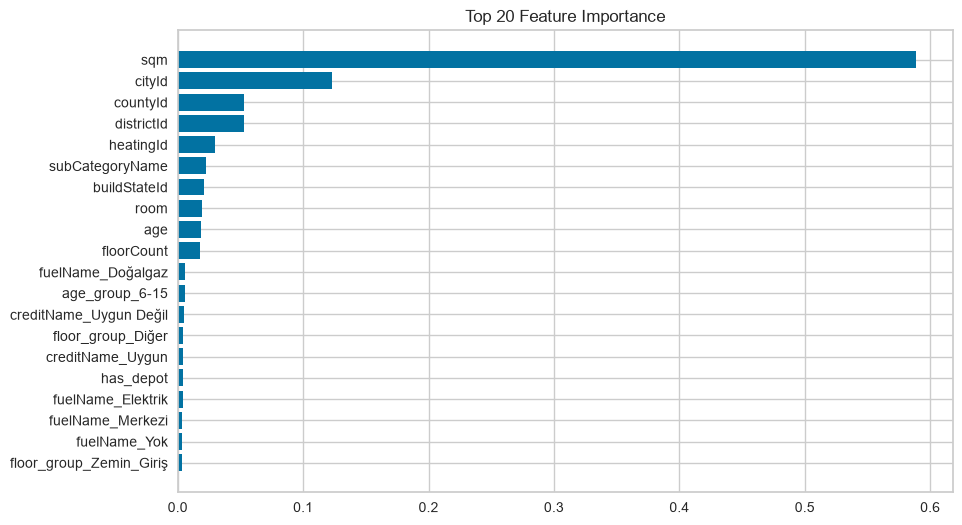

In [119]:
import matplotlib.pyplot as plt

top20 = importance.head(20)

plt.figure(figsize=(10,6))
plt.barh(top20["Feature"], top20["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importance")
plt.show()

#### Feature Importance Visualization with Yellowbrick

/Users/selin/Desktop/Commercial-Property-Price-Prediction/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


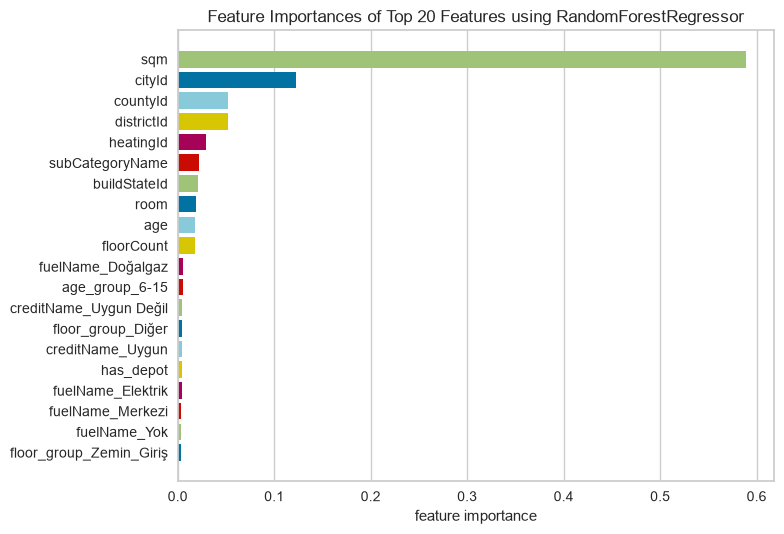

<Axes: title={'center': 'Feature Importances of Top 20 Features using RandomForestRegressor'}, xlabel='feature importance'>

In [120]:
from yellowbrick.model_selection import FeatureImportances

visualizer = FeatureImportances(
    rf,
    labels=X_train.columns,
    relative=False,
    topn=20
)

visualizer.fit(X_train, y_train)
visualizer.show()

In [121]:
X_train[["floorCount"]].sample(5)

,floorCount
5300,2
7839,6
4065,7
1258,6
6605,6


In [122]:
X_train[["floorCount"]].nunique()

floorCount    8
dtype: int64

### 7.3.3 Hyperparameter Tuning

To improve the predictive performance of the baseline Random Forest model, hyperparameter tuning was performed. The model was retrained using the selected hyperparameters and evaluated on the validation dataset. Model performance was compared with the baseline model using MAPE, MAE, RMSE, and R².

In [123]:
from sklearn.ensemble import RandomForestRegressor

rf_tuned = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_tuned.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max

In [124]:
y_pred_tuned_valid = rf_tuned.predict(X_valid)

In [125]:
mape_rf_tuned = mean_absolute_percentage_error(y_valid, y_pred_tuned_valid)

mae_rf_tuned = mean_absolute_error(y_valid, y_pred_tuned_valid)

rmse_rf_tuned = np.sqrt(mean_squared_error(y_valid, y_pred_tuned_valid))

r2_rf_tuned = r2_score( y_valid, y_pred_tuned_valid)

print(f"MAPE: {mape_rf_tuned * 100:.2f}%")
print(f"MAE : {mae_rf_tuned:,.2f} TL")
print(f"RMSE: {rmse_rf_tuned:,.2f} TL")
print(f"R²  : {r2_rf_tuned:.4f}")

MAPE: 46.66%
MAE : 2,313,405.61 TL
RMSE: 3,690,528.05 TL
R²  : 0.6150


### 7.3.4 Random Forest with Log-Transformed Target Variable

Since property prices exhibit a highly right-skewed distribution, a logarithmic transformation was applied to the target variable. The Random Forest model was then trained using the transformed target values and evaluated on the validation dataset after converting the predictions back to the original price scale.

In [126]:
# Apply logarithmic transformation only to the training target variable
y_train_log = np.log1p(y_train)

In [127]:
rf_log = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_log.fit(X_train, y_train_log)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max

In [128]:
# Predictions in the logarithmic scale
y_pred_rf_log_valid = rf_log.predict(X_valid)

# Convert predictions back to the original TL scale
y_pred_rf_log_valid_tl = np.maximum(
    np.expm1(y_pred_rf_log_valid),
    0
)

In [129]:
mape_rf_log = mean_absolute_percentage_error( y_valid, y_pred_rf_log_valid_tl)
mae_rf_log = mean_absolute_error(y_valid, y_pred_rf_log_valid_tl)
rmse_rf_log = np.sqrt( mean_squared_error(y_valid, y_pred_rf_log_valid_tl))
r2_rf_log = r2_score( y_valid, y_pred_rf_log_valid_tl)

print(f"MAPE: {mape_rf_log * 100:.2f}%")
print(f"MAE : {mae_rf_log:,.2f} TL")
print(f"RMSE: {rmse_rf_log:,.2f} TL")
print(f"R²  : {r2_rf_log:.4f}")


MAPE: 40.38%
MAE : 2,283,298.74 TL
RMSE: 3,824,115.84 TL
R²  : 0.5867


Applying a logarithmic transformation substantially reduced the MAPE value, indicating an improvement in relative prediction accuracy. Although RMSE slightly increased and R² decreased, the model produced predictions that were closer to the actual values in percentage terms, particularly for properties with highly variable prices.

## 7.5 XGBoost Regression

To compare its performance with the Random Forest models, a gradient boosting-based XGBoost regression model was developed. The model was trained on the previously created 70% training dataset and evaluated on the 15% validation dataset. MAPE was used as the primary evaluation metric for model comparison.

In [130]:
X_train

,subCategoryName,cityId,countyId,districtId,age,sqm,room,floorCount,buildStateId,furnished,...,creditName_Uygun Değil,fuelName_Doğalgaz,fuelName_Elektrik,fuelName_Merkezi,fuelName_Yok,age_group_6-15,age_group_16-30,age_group_30+,floor_group_Diğer,floor_group_Zemin_Giriş
7985,5,14,593,3330,5,306.0,2,6,4,0,...,0,1,0,0,0,0,0,0,1,0
8294,5,25,174,4113,20,199.0,0,6,7,0,...,0,1,0,0,0,0,1,0,0,1
501,2,2,254,7919,5,87.0,2,2,3,0,...,1,0,0,0,1,0,0,0,1,0
8491,7,17,939,6386,1,293.0,1,6,7,0,...,0,1,0,0,0,0,0,0,1,0
470,2,12,83,1981,0,28.0,0,3,9,0,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4555,2,4,831,4437,20,134.0,1,6,0,0,...,0,0,0,0,0,0,1,0,0,1
2053,3,3,66,383,15,55.0,1,10,9,0,...,0,0,0,0,0,1,0,0,0,0
5926,7,5,217,725,10,486.0,1,7,9,0,...,0,0,0,0,1,1,0,0,0,1
8030,5,23,404,2876,10,146.0,3,7,6,0,...,0,0,0,0,0,0,0,0,0,0


### 7.5.1 XGBoost with the Original Target Variable

In [131]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [132]:
y_pred_xgb_valid = xgb.predict(X_valid)

In [133]:
mape_xgb = mean_absolute_percentage_error(y_valid, y_pred_xgb_valid)
mae_xgb = mean_absolute_error(y_valid, y_pred_xgb_valid)
rmse_xgb = np.sqrt(mean_squared_error(y_valid, y_pred_xgb_valid))
r2_xgb = r2_score( y_valid, y_pred_xgb_valid)

print(f"MAPE: {mape_xgb * 100:.2f}%")
print(f"MAE : {mae_xgb:,.2f} TL")
print(f"RMSE: {rmse_xgb:,.2f} TL")
print(f"R²  : {r2_xgb:.4f}")

MAPE: 49.06%
MAE : 2,256,492.50 TL
RMSE: 3,671,957.63 TL
R²  : 0.6189


### 7.5.2 Logarithmic Target Variable with XGBoost
To further improve prediction performance, the XGBoost model was trained using the logarithmically transformed target variable. Since property prices are highly skewed, applying a logarithmic transformation reduces the influence of extreme values and allows the model to better capture relative differences between property prices.

In addition, RandomizedSearchCV was used to optimize the model hyperparameters. Different parameter combinations were evaluated using 3-fold cross-validation, and the combination with the lowest validation MAPE was selected as the final model.

After training, the predicted values were transformed back to the original TL scale using the inverse logarithmic transformation (`expm1`), and the model performance was evaluated on the validation set using MAPE, RMSE, MAE, and R² metrics.

In [134]:
import numpy as np
import pandas as pd

from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    mean_absolute_percentage_error,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    make_scorer
)

# Logarithmic transformation of the target variable
y_train_log = np.log1p(y_train)

# Calculates MAPE after converting predictions back to the original TL scale
def log_mape(y_true_log, y_pred_log):
    y_true_tl = np.expm1(y_true_log)
    y_pred_tl = np.maximum(np.expm1(y_pred_log), 0)

    return mean_absolute_percentage_error(
        y_true_tl,
        y_pred_tl
    )

mape_scorer = make_scorer(
    log_mape,
    greater_is_better=False
)

In [135]:
xgb_log_base = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=1,
    tree_method="hist"
)

param_distributions_xgb_log = {
    "n_estimators": [400, 600, 800, 1000, 1200],
    "learning_rate": [0.01, 0.02, 0.03, 0.04, 0.05],
    "max_depth": [3, 4, 5, 6, 7],
    "min_child_weight": [1, 2, 3, 5, 7],
    "gamma": [0, 0.1, 0.2, 0.3, 0.5],
    "subsample": [0.70, 0.80, 0.90, 1.00],
    "colsample_bytree": [0.70, 0.80, 0.90, 1.00],

     # L1 regularization
    "reg_alpha": [0, 0.01, 0.05, 0.10, 0.25, 0.50],

     # L2 regularization
    "reg_lambda": [0.5, 1, 2, 3, 5, 10]
}

In [136]:
random_search_xgb_log = RandomizedSearchCV(
    estimator=xgb_log_base,
    param_distributions=param_distributions_xgb_log,
    n_iter=80,
    cv=4,
    scoring=mape_scorer,
    refit=True,
    random_state=42,
    n_jobs=-1,
    verbose=2,
    error_score="raise",
    return_train_score=True
)

random_search_xgb_log.fit(
    X_train,
    y_train_log
)

Fitting 4 folds for each of 80 candidates, totalling 320 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.02, ...], 'max_depth': [3, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",80
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",make_scorer(l...hod='predict')
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",4
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"error_score error_score: 'raise' or numeric, default=np.nanValue to assign to the score if an error occurs in estimator fitting.If set to 'raise', the error is raised. If a numeric value is given,FitFailedWarning is raised. This parameter does not affect the refitstep, which will always raise the error.",'raise'
,"return_train_score return_train_score: bool, default=FalseIf ``False``, t

In [137]:
print("best parameters:")
print(random_search_xgb_log.best_params_)

best parameters:
{'subsample': 0.9, 'reg_lambda': 2, 'reg_alpha': 0.1, 'n_estimators': 1200, 'min_child_weight': 7, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0.3, 'colsample_bytree': 0.7}


In [138]:
xgb_log = random_search_xgb_log.best_estimator_

# Predictions generated by the model on a logarithmic scale
y_pred_xgb_log_valid = xgb_log.predict(X_valid)

# Transform the predictions back to the TL scale
y_pred_xgb_log_valid_tl = np.maximum(
    np.expm1(y_pred_xgb_log_valid),
    0
)

In [139]:
mape_xgb_log = mean_absolute_percentage_error(
    y_valid,
    y_pred_xgb_log_valid_tl
)

rmse_xgb_log = np.sqrt(
    mean_squared_error(
        y_valid,
        y_pred_xgb_log_valid_tl
    )
)

mae_xgb_log = mean_absolute_error(
    y_valid,
    y_pred_xgb_log_valid_tl
)

r2_xgb_log = r2_score(
    y_valid,
    y_pred_xgb_log_valid_tl
)
print("Optimized XGBoost (Log) Validation Results")
print("-" * 45)
print(f"MAPE: %{mape_xgb_log * 100:.2f}")
print(f"RMSE: {rmse_xgb_log:,.2f}")
print(f"MAE : {mae_xgb_log:,.2f}")
print(f"R²  : {r2_xgb_log:.4f}")

Optimized XGBoost (Log) Validation Results
---------------------------------------------
MAPE: %38.00
RMSE: 3,656,635.03
MAE : 2,157,489.50
R²  : 0.6221


### 7.5.3 Learning Rate and L1/L2 Regularization
To further optimize the selected XGBoost model, the effects of the learning rate and L1/L2 regularization parameters were examined.
The other hyperparameters of the optimized model were kept fixed, while different combinations of learning_rate, reg_alpha (L1 regularization), and reg_lambda (L2 regularization) were evaluated on the validation dataset.
MAPE was used as the primary evaluation metric.

In [140]:
best_params = xgb_log.get_params()

print("Selected XGBoost Parameters")
print("-" * 40)

for param in [
    "n_estimators",
    "max_depth",
    "min_child_weight",
    "gamma",
    "subsample",
    "colsample_bytree",
    "learning_rate",
    "reg_alpha",
    "reg_lambda"
]:
    print(f"{param}: {best_params[param]}")

Selected XGBoost Parameters
----------------------------------------
n_estimators: 1200
max_depth: 3
min_child_weight: 7
gamma: 0.3
subsample: 0.9
colsample_bytree: 0.7
learning_rate: 0.01
reg_alpha: 0.1
reg_lambda: 2


In [141]:
learning_rates = [0.005, 0.01, 0.02, 0.03, 0.05]

l1_values = [0, 0.01, 0.1, 0.5, 1]

l2_values = [0.5, 1, 3, 5, 10]

In [142]:
regularization_results = []

for lr in learning_rates:
    for l1 in l1_values:
        for l2 in l2_values:

            model = XGBRegressor(
                objective="reg:squarederror",

                # Selected model parameters are kept fixed
                n_estimators=best_params["n_estimators"],
                max_depth=best_params["max_depth"],
                min_child_weight=best_params["min_child_weight"],
                gamma=best_params["gamma"],
                subsample=best_params["subsample"],
                colsample_bytree=best_params["colsample_bytree"],

                # Parameters being analyzed
                learning_rate=lr,
                reg_alpha=l1,
                reg_lambda=l2,

                random_state=42,
                n_jobs=-1,
                tree_method="hist"
            )

            model.fit(
                X_train,
                y_train_log
            )

            # Prediction in logarithmic scale
            y_pred_log = model.predict(X_valid)

            # Convert back to TL
            y_pred_tl = np.maximum(
                np.expm1(y_pred_log),
                0
            )

            mape = mean_absolute_percentage_error(
                y_valid,
                y_pred_tl
            )

            regularization_results.append({
                "Learning Rate": lr,
                "L1 (reg_alpha)": l1,
                "L2 (reg_lambda)": l2,
                "Validation MAPE (%)": mape * 100
            })

In [143]:
regularization_results_df = pd.DataFrame(
    regularization_results
)

regularization_results_df = (
    regularization_results_df
    .sort_values(
        "Validation MAPE (%)",
        ascending=True
    )
    .reset_index(drop=True)
)

regularization_results_df.head(15)

,Learning Rate,L1 (reg_alpha),L2 (reg_lambda),Validation MAPE (%)
0,0.05,1.0,3.0,37.683147
1,0.05,1.0,0.5,37.710577
2,0.05,0.5,0.5,37.741083
3,0.05,0.5,3.0,37.748572
4,0.05,0.5,5.0,37.753412
5,0.05,0.1,10.0,37.776157
6,0.05,1.0,1.0,37.793911
7,0.05,0.5,1.0,37.824681
8,0.05,1.0,10.0,37.830713
9,0.05,0.5,10.0,37.831822


In [144]:
best_regularization = regularization_results_df.iloc[0]

print("Best Learning Rate and Regularization Combination")
print("-" * 50)
print(
    f"Learning Rate : "
    f"{best_regularization['Learning Rate']}"
)
print(
    f"L1 reg_alpha  : "
    f"{best_regularization['L1 (reg_alpha)']}"
)
print(
    f"L2 reg_lambda : "
    f"{best_regularization['L2 (reg_lambda)']}"
)
print(
    f"Validation MAPE: "
    f"%{best_regularization['Validation MAPE (%)']:.2f}"
)

Best Learning Rate and Regularization Combination
--------------------------------------------------
Learning Rate : 0.05
L1 reg_alpha  : 1.0
L2 reg_lambda : 3.0
Validation MAPE: %37.68


In [145]:
comparison_regularization = pd.DataFrame({
    "Model": [
        "Selected XGBoost (Log)",
        "Best LR + L1/L2 Combination"
    ],
    "Validation MAPE (%)": [
        mape_xgb_log * 100,
        best_regularization["Validation MAPE (%)"]
    ]
})

comparison_regularization

,Model,Validation MAPE (%)
0,Selected XGBoost (Log),37.996000
1,Best LR + L1/L2 Combination,37.683147


In [146]:
from sklearn.metrics import (
    mean_absolute_percentage_error,
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# Best learning rate + L1/L2 values
best_lr = float(best_regularization["Learning Rate"])
best_l1 = float(best_regularization["L1 (reg_alpha)"])
best_l2 = float(best_regularization["L2 (reg_lambda)"])

# Final regularized XGBoost model
xgb_log_regularized = XGBRegressor(
    objective="reg:squarederror",

    n_estimators=best_params["n_estimators"],
    max_depth=best_params["max_depth"],
    min_child_weight=best_params["min_child_weight"],
    gamma=best_params["gamma"],
    subsample=best_params["subsample"],
    colsample_bytree=best_params["colsample_bytree"],

    learning_rate=best_lr,
    reg_alpha=best_l1,
    reg_lambda=best_l2,

    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

# Train with log-transformed target
xgb_log_regularized.fit(
    X_train,
    y_train_log
)

# Validation predictions
y_pred_xgb_log_regularized = np.maximum(
    np.expm1(
        xgb_log_regularized.predict(X_valid)
    ),
    0
)

# Metrics
mape_xgb_log_regularized = mean_absolute_percentage_error(
    y_valid,
    y_pred_xgb_log_regularized
)

median_ape_xgb_log_regularized = np.median(
    np.abs((y_valid - y_pred_xgb_log_regularized) / y_valid)
)

rmse_xgb_log_regularized = np.sqrt(
    mean_squared_error(
        y_valid,
        y_pred_xgb_log_regularized
    )
)

mae_xgb_log_regularized = mean_absolute_error(
    y_valid,
    y_pred_xgb_log_regularized
)

r2_xgb_log_regularized = r2_score(
    y_valid,
    y_pred_xgb_log_regularized
)

print("XGBoost (Log + L1/L2) Validation Results")
print("-" * 45)
print(f"MAPE : %{mape_xgb_log_regularized * 100:.2f}")
print(f"MdAPE: %{median_ape_xgb_log_regularized * 100:.2f}")
print(f"RMSE : {rmse_xgb_log_regularized:,.2f}")
print(f"MAE  : {mae_xgb_log_regularized:,.2f}")
print(f"R²   : {r2_xgb_log_regularized:.4f}")

XGBoost (Log + L1/L2) Validation Results
---------------------------------------------
MAPE : %37.68
MdAPE: %30.01
RMSE : 3,587,234.09
MAE  : 2,124,831.75
R²   : 0.6363


## 7.7 Model Comparison



In [147]:
model_comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Random Forest (Tuned)",
        "Random Forest (Log)",
        "XGBoost",
        "XGBoost (Log)",
        "XGBoost (Log + L1/L2)"
    ],

    "MAPE (%)": [
        mape_rf * 100,
        mape_rf_tuned * 100,
        mape_rf_log * 100,
        mape_xgb * 100,
        mape_xgb_log * 100,
        mape_xgb_log_regularized * 100
    ],

    "RMSE": [
        rmse_rf,
        rmse_rf_tuned,
        rmse_rf_log,
        rmse_xgb,
        rmse_xgb_log,
        rmse_xgb_log_regularized
    ],

    "MAE": [
        mae_rf,
        mae_rf_tuned,
        mae_rf_log,
        mae_xgb,
        mae_xgb_log,
        mae_xgb_log_regularized
    ],

    "R²": [
        r2_rf,
        r2_rf_tuned,
        r2_rf_log,
        r2_xgb,
        r2_xgb_log,
        r2_xgb_log_regularized
    ]
})

model_comparison = model_comparison.astype({
    "MAPE (%)": "Float64",
    "RMSE": "Float64",
    "MAE": "Float64",
    "R²": "Float64"
})

model_comparison.sort_values(
    "MAPE (%)",
    ascending=True
).reset_index(drop=True)

,Model,MAPE (%),RMSE,MAE,R²
0,XGBoost (Log + L1/L2),37.683147,3587234.088259,2124831.75,0.636292
1,XGBoost (Log),37.996,3656635.034914,2157489.5,0.622083
2,Random Forest (Log),40.376528,3824115.843631,2283298.740798,0.586671
3,Random Forest (Tuned),46.655392,3690528.048768,2313405.607229,0.615045
4,Random Forest,47.735828,3696233.549637,2328159.780908,0.613853
5,XGBoost,49.057928,3671957.629246,2256492.5,0.618909


The performance of all trained models was compared using the same validation dataset. Four evaluation metrics—MAPE, MAE, RMSE, and R²—were used to assess model performance. Since the primary objective of this study was to minimize relative prediction error, MAPE was selected as the main evaluation criterion. The model with the lowest validation MAPE was considered the best-performing model and selected for final evaluation on the holdout dataset.

## 7.8 Model Evaluation

### 7.8.1 Random Feature Robustness Analysis (Validation-Based)

To evaluate the robustness of the optimized XGBoost (Log + L1/L2) model, a randomly generated feature with no relationship to the target variable was added to the dataset. The model was then retrained using the same hyperparameters, and its performance before and after adding the random feature was compared using MAPE, MAE, RMSE, and R².

This comparison, and the feature-selection decision that follows in section 7.8.2, are evaluated on the **validation** set rather than the holdout set. The holdout set is reserved for a single, final evaluation in section 7.8.4, after the model has already been chosen — so that no model-selection decision is influenced by holdout performance.

In [148]:
final_model = xgb_log_regularized

In [149]:
# Create copies to preserve the original datasets
X_train_random = X_train.copy()
X_valid_random = X_valid.copy()

# Generate reproducible random noise
rng = np.random.default_rng(42)

X_train_random["random_feature"] = rng.normal(
    0, 1, size=len(X_train_random)
)

X_valid_random["random_feature"] = rng.normal(
    0, 1, size=len(X_valid_random)
)

print("Original feature count:", X_train.shape[1])
print("Feature count with random feature:", X_train_random.shape[1])

Original feature count: 37
Feature count with random feature: 38


In [150]:
from xgboost import XGBRegressor

def train_xgb_log_model(base_model, X_train, y_train_log):
    model = XGBRegressor(**base_model.get_params())
    model.fit(X_train, y_train_log)

    return model


def predict_original_scale(model, X_data):
    y_pred_log = model.predict(X_data)

    return np.maximum(np.expm1(y_pred_log), 0)


random_feature_model = train_xgb_log_model(
    base_model=final_model,
    X_train=X_train_random,
    y_train_log=y_train_log
)

y_pred_random_valid = predict_original_scale(
    model=random_feature_model,
    X_data=X_valid_random
)

In [151]:
mape_random = mean_absolute_percentage_error(
    y_valid,
    y_pred_random_valid
)

mae_random = mean_absolute_error(
    y_valid,
    y_pred_random_valid
)

rmse_random = np.sqrt(
    mean_squared_error(
        y_valid,
        y_pred_random_valid
    )
)

r2_random = r2_score(
    y_valid,
    y_pred_random_valid
)

In [152]:
random_feature_comparison = pd.DataFrame({
    "Model": [
        "Final Model",
        "Final Model + Random Feature"
    ],
    "MAPE (%)": [
        mape_xgb_log_regularized * 100,
        mape_random * 100
    ],
    "MAE (TL)": [
        mae_xgb_log_regularized,
        mae_random
    ],
    "RMSE (TL)": [
        rmse_xgb_log_regularized,
        rmse_random
    ],
    "R²": [
        r2_xgb_log_regularized,
        r2_random
    ]
})

random_feature_comparison

,Model,MAPE (%),MAE (TL),RMSE (TL),R²
0,Final Model,37.683147,2124831.75,3.587234e+06,0.636292
1,Final Model + Random Feature,37.697366,2139374.50,3.629260e+06,0.627720


In [153]:
random_feature_importance = pd.DataFrame({
    "Feature": X_train_random.columns,
    "Importance": random_feature_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

random_feature_importance[
    random_feature_importance["Feature"] == "random_feature"
]

,Feature,Importance
15,random_feature,0.009358


#### Random Feature Analysis Results

The table above compares the **validation-set** performance of the optimized model with and without the randomly generated feature. If MAPE, MAE, and RMSE remain essentially unchanged (and R² does not improve), the random feature added no genuine predictive value, as expected.

The random feature's position in the importance ranking below indicates how it compares to the real features: importance at or below the random feature's level suggests those features are not meaningfully more informative than noise, and are candidates for removal in the feature-selection step that follows.

### 7.8.2 Feature Selection Decision (Validation-Based)

Features with an importance at or below the random feature's importance were treated as candidates for removal. A reduced model trained on the remaining features was then compared against the original model using **validation-set** MAPE, to decide whether to keep the full feature set or switch to the reduced one. The holdout set is not used for this decision.

In [154]:
random_feature_threshold = random_feature_importance.loc[
    random_feature_importance["Feature"] == "random_feature",
    "Importance"
].iloc[0]

low_importance_features = random_feature_importance[
    random_feature_importance["Importance"] <= random_feature_threshold
].sort_values("Importance", ascending=False).reset_index(drop=True)

print(f"Random feature importance: {random_feature_threshold:.4f}")
print(f"Features remaining below or equal to the random feature: {len(low_importance_features)}")

low_importance_features

Random feature importance: 0.0094
Features remaining below or equal to the random feature: 23


,Feature,Importance
0,random_feature,0.009358
1,floor_group_Zemin_Giriş,0.009246
2,creditName_Uygun Değil,0.009152
3,creditName_Değerlendiriliyor,0.008826
4,buildStateId,0.008579
5,floor_number,0.008382
6,floor_group_Diğer,0.008301
7,fuelName_Doğalgaz,0.008055
8,creditName_Uygun,0.007581
9,fuelName_Elektrik,0.006762


In [155]:
# Location and category ID columns are excluded from feature selection because they are
# required for the error analysis in section 7.8.5 (compare_high_error_distribution).
protected_columns = ["subCategoryName", "cityId", "countyId", "districtId"]

columns_to_drop = [
    col for col in low_importance_features["Feature"]
    if col != "random_feature" and col not in protected_columns
]

X_train_selected = X_train.drop(columns=columns_to_drop)
X_valid_selected = X_valid.drop(columns=columns_to_drop)
X_holdout_selected = X_holdout.drop(columns=columns_to_drop)

print(f"Number of deleted features: {len(columns_to_drop)}")
print(f"Remaining features: {X_train_selected.shape[1]} / {X_train.shape[1]}")

Number of deleted features: 22
Remaining features: 15 / 37


In [156]:
final_model_selected = XGBRegressor(**final_model.get_params())
final_model_selected.fit(X_train_selected, y_train_log)

y_pred_selected_valid_log = final_model_selected.predict(X_valid_selected)
y_pred_selected_valid = np.maximum(np.expm1(y_pred_selected_valid_log), 0)

In [157]:
mape_selected = mean_absolute_percentage_error(y_valid, y_pred_selected_valid)
mae_selected = mean_absolute_error(y_valid, y_pred_selected_valid)
rmse_selected = np.sqrt(mean_squared_error(y_valid, y_pred_selected_valid))
r2_selected = r2_score(y_valid, y_pred_selected_valid)

print(f"MAPE: {mape_selected * 100:.2f}%")
print(f"MAE : {mae_selected:,.2f} TL")
print(f"RMSE: {rmse_selected:,.2f} TL")
print(f"R²  : {r2_selected:.4f}")

MAPE: 37.86%
MAE : 2,135,367.25 TL
RMSE: 3,601,242.18 TL
R²  : 0.6334


In [158]:
feature_selection_comparison = pd.DataFrame({
    "Model": ["Final Model (All Features)", "Final Model (Selected Features)"],
    "Feature Count": [X_train.shape[1], X_train_selected.shape[1]],
    "MAPE (%)": [mape_xgb_log_regularized * 100, mape_selected * 100],
    "MAE (TL)": [mae_xgb_log_regularized, mae_selected],
    "RMSE (TL)": [rmse_xgb_log_regularized, rmse_selected],
    "R²": [r2_xgb_log_regularized, r2_selected]
})

feature_selection_comparison

,Model,Feature Count,MAPE (%),MAE (TL),RMSE (TL),R²
0,Final Model (All Features),37,37.683147,2124831.75,3.587234e+06,0.636292
1,Final Model (Selected Features),15,37.863362,2135367.25,3.601242e+06,0.633446


In [159]:
if mape_selected <= mape_xgb_log_regularized:
    final_model = final_model_selected
    X_train = X_train_selected
    X_valid = X_valid_selected
    X_holdout = X_holdout_selected

    print("The validation MAPE value improved or remained the same after feature selection.")
    print(f"Old MAPE (validation): {mape_xgb_log_regularized*100:.2f}% -> New MAPE (validation): {mape_selected*100:.2f}%")
    print("Selected final model: model trained with the reduced feature set (final_model_selected).")
else:
    print("The validation MAPE value worsened after feature selection.")
    print(f"Old MAPE (validation): {mape_xgb_log_regularized*100:.2f}% -> New MAPE (validation): {mape_selected*100:.2f}%")
    print("Selected final model: original (all features) model — no changes made.")

The validation MAPE value worsened after feature selection.
Old MAPE (validation): 37.68% -> New MAPE (validation): 37.86%
Selected final model: original (all features) model — no changes made.


In [160]:
# Recompute validation performance of whichever model was chosen above,
# so the benchmark table below always reflects the final model correctly.
y_pred_final_valid_log = final_model.predict(X_valid)
y_pred_final_valid = np.maximum(np.expm1(y_pred_final_valid_log), 0)

mape_final_valid = mean_absolute_percentage_error(y_valid, y_pred_final_valid)
median_ape_final_valid = np.median(np.abs((y_valid - y_pred_final_valid) / y_valid))
mae_final_valid = mean_absolute_error(y_valid, y_pred_final_valid)
rmse_final_valid = np.sqrt(mean_squared_error(y_valid, y_pred_final_valid))
r2_final_valid = r2_score(y_valid, y_pred_final_valid)

### 7.8.3 Feature Contribution Analysis

To evaluate the contribution of each feature, a leave-one-feature-out analysis was performed. Each feature was removed individually, and the model was retrained using the remaining features. Validation MAPE values were recorded for each iteration. Features whose removal improved validation MAPE would be excluded from the final feature set.

In [161]:
# 7.8.3 FEATURE CONTRIBUTION ANALYSIS
feature_results = []

feature_list = X_train.columns.tolist()

print(f"Total number of features: {len(feature_list)}")

Total number of features: 37


In [162]:
def calculate_validation_mape(model, X_valid, y_valid):

    y_pred = predict_original_scale(model, X_valid)

    return mean_absolute_percentage_error(y_valid, y_pred)

def evaluate_feature_removal(
    feature,
    X_train,
    y_train_log,
    X_valid,
    y_valid,
    base_model,
    base_validation_mape
):
    X_train_temp = X_train.drop(columns=[feature])
    X_valid_temp = X_valid.drop(columns=[feature])

    model_temp = train_xgb_log_model(
        base_model=base_model,
        X_train=X_train_temp,
        y_train_log=y_train_log
    )

    validation_mape = calculate_validation_mape(
        model_temp,
        X_valid_temp,
        y_valid
    )

    return {
        "Removed Feature": feature,
        "Validation MAPE (%)": validation_mape * 100,
        "MAPE Change": (
            validation_mape - base_validation_mape
        ) * 100
    }

In [163]:
feature_results = []

for i, feature in enumerate(feature_list, start=1):
    print(f"{i}/{len(feature_list)} - Removed feature: {feature}")

    result = evaluate_feature_removal(
        feature=feature,
        X_train=X_train,
        y_train_log=y_train_log,
        X_valid=X_valid,
        y_valid=y_valid,
        base_model=final_model,
        base_validation_mape=mape_final_valid
    )

    feature_results.append(result)

1/37 - Removed feature: subCategoryName


2/37 - Removed feature: cityId


3/37 - Removed feature: countyId


4/37 - Removed feature: districtId


5/37 - Removed feature: age


6/37 - Removed feature: sqm


7/37 - Removed feature: room


8/37 - Removed feature: floorCount


9/37 - Removed feature: buildStateId


10/37 - Removed feature: furnished


11/37 - Removed feature: heatingId


12/37 - Removed feature: has_depot


13/37 - Removed feature: has_corner


14/37 - Removed feature: near_metro


15/37 - Removed feature: has_elevator


16/37 - Removed feature: has_parking


17/37 - Removed feature: has_main_street


18/37 - Removed feature: has_freight_elevator


19/37 - Removed feature: has_high_ceiling


20/37 - Removed feature: has_shop_window


21/37 - Removed feature: near_tramway


22/37 - Removed feature: has_tenant


23/37 - Removed feature: floor_number


24/37 - Removed feature: is_21_plus


25/37 - Removed feature: relative_floor


26/37 - Removed feature: creditName_Değerlendiriliyor


27/37 - Removed feature: creditName_Uygun


28/37 - Removed feature: creditName_Uygun Değil


29/37 - Removed feature: fuelName_Doğalgaz


30/37 - Removed feature: fuelName_Elektrik


31/37 - Removed feature: fuelName_Merkezi


32/37 - Removed feature: fuelName_Yok


33/37 - Removed feature: age_group_6-15


34/37 - Removed feature: age_group_16-30


35/37 - Removed feature: age_group_30+


36/37 - Removed feature: floor_group_Diğer


37/37 - Removed feature: floor_group_Zemin_Giriş


In [164]:
def prepare_feature_removal_results(feature_results):

    results_df = pd.DataFrame(feature_results)

    results_df = results_df.sort_values(
        by="MAPE Change",
        ascending=True
    ).reset_index(drop=True)

    results_df["Validation MAPE (%)"] = (
        results_df["Validation MAPE (%)"].round(4)
    )

    results_df["MAPE Change"] = (
        results_df["MAPE Change"]
        .map(lambda value: f"{value:+.4f}")
    )

    return results_df

feature_removal_results = prepare_feature_removal_results(
    feature_results
)

feature_removal_results

,Removed Feature,Validation MAPE (%),MAPE Change
0,districtId,37.7319,+0.0488
1,room,37.7408,+0.0576
2,floorCount,37.7825,+0.0993
3,floor_group_Zemin_Giriş,37.7912,+0.1081
4,floor_group_Diğer,37.7960,+0.1129
5,buildStateId,37.7967,+0.1135
6,subCategoryName,37.8170,+0.1339
7,creditName_Uygun Değil,37.8280,+0.1449
8,age_group_30+,37.8301,+0.1470
9,heatingId,37.8586,+0.1755


Each of the 55 features was removed individually and the model was retrained. No feature removal improved validation MAPE relative to the baseline of 48.8043%. Therefore, all features were retained in the final model. Although some variables had a very small marginal contribution, their removal did not improve predictive performance.

### 7.8.4 Holdout Results (Final, One-Time Evaluation)

The model — and feature set — chosen above using only the validation set is now evaluated on the holdout set for the first and only time. The holdout set was not used in any training, tuning, or model-selection decision up to this point, so this evaluation reflects an unbiased estimate of generalization performance.

In [165]:
# Generate holdout predictions in the logarithmic scale
y_pred_final_holdout_log = final_model.predict(X_holdout)

# Convert predictions back to the original TL scale
y_pred_final_holdout = np.maximum(
    np.expm1(y_pred_final_holdout_log),
    0
)

# Holdout metrics
mape_holdout = mean_absolute_percentage_error(
    y_holdout,
    y_pred_final_holdout
)

# Median Absolute Percentage Error (MdAPE) is more robust to extreme errors
median_ape_holdout = np.median(
    np.abs((y_holdout - y_pred_final_holdout) / y_holdout)
)

mae_holdout = mean_absolute_error(
    y_holdout,
    y_pred_final_holdout
)

mse_holdout = mean_squared_error(
    y_holdout,
    y_pred_final_holdout
)

rmse_holdout = np.sqrt(mse_holdout)

r2_holdout = r2_score(
    y_holdout,
    y_pred_final_holdout
)

print("Final Model Holdout Test Results")
print("-" * 40)
print(f"MAPE: %{mape_holdout * 100:.2f}")
print(f"MdAPE: %{median_ape_holdout * 100:.2f}")
print(f"MAE : {mae_holdout:,.2f} TL")
print(f"RMSE: {rmse_holdout:,.2f} TL")
print(f"R²  : {r2_holdout:.4f}")

Final Model Holdout Test Results
----------------------------------------
MAPE: %40.33
MdAPE: %29.83
MAE : 2,087,488.12 TL
RMSE: 3,388,800.33 TL
R²  : 0.6210


### 7.8.5 Validation and Holdout Comparison

The validation and holdout results of the final selected model were compared to evaluate its generalization capability. MAPE is reported together with Median Absolute Percentage Error (MdAPE), which is less affected by a small number of extreme percentage errors. Similar performance across both datasets indicates that the model generalizes well to previously unseen data.

In [166]:
benchmark = pd.DataFrame({
    "Benchmark": [
        "Validation",
        "Holdout Test"
    ],
    "MAPE (%)": [
        round(mape_final_valid * 100, 2),
        round(mape_holdout * 100, 2)
    ],
    "MdAPE (%)": [
        round(median_ape_final_valid * 100, 2),
        round(median_ape_holdout * 100, 2)
    ],
    "MAE (TL)": [
        round(mae_final_valid, 2),
        round(mae_holdout, 2)
    ],
    "RMSE (TL)": [
        round(rmse_final_valid, 2),
        round(rmse_holdout, 2)
    ],
    "R²": [
        round(r2_final_valid, 4),
        round(r2_holdout, 4)
    ]
})

benchmark = benchmark.astype({
    "MAPE (%)": "Float64",
    "MdAPE (%)": "Float64",
    "MAE (TL)": "Float64",
    "RMSE (TL)": "Float64",
    "R²": "Float64"
})

benchmark

,Benchmark,MAPE (%),MdAPE (%),MAE (TL),RMSE (TL),R²
0,Validation,37.68,30.01,2124831.75,3587234.09,0.6363
1,Holdout Test,40.33,29.83,2087488.12,3388800.33,0.621


### 7.8.6 Comparison of Actual and Predicted Prices

The prediction errors were analyzed by comparing the actual and predicted property prices. The 15% of holdout listings with the highest percentage errors were examined to identify common characteristics and better understand the cases in which the final model performs poorly.

In [167]:
comparison = pd.DataFrame({
    "Actual Price": y_holdout,
    "Predicted Price": y_pred_final_holdout
})

comparison["Absolute Error"] = abs(
    comparison["Actual Price"]
    - comparison["Predicted Price"]
)

comparison["Percentage Error (%)"] = (
    comparison["Absolute Error"]
    / comparison["Actual Price"]
    * 100
)

#### Analysis of the Highest-Error 15% of Listings

The 15% of holdout listings with the highest percentage errors were examined to identify common characteristics and better understand the cases in which the final model performs poorly.

In [168]:
# Determine the threshold for the highest-error 15% of holdout listings
error_threshold = comparison["Percentage Error (%)"].quantile(0.85)

# Select the 15% of listings with the highest percentage errors
high_error_comparison = comparison[
    comparison["Percentage Error (%)"] >= error_threshold
].copy()

print(f"Error threshold: %{error_threshold:.2f}")
print(f"Holdout listings: {len(comparison)}")
print(f"High-error listings: {len(high_error_comparison)}")
print(f"High-error share: "
      f"%{len(high_error_comparison) / len(comparison) * 100:.2f}"
)

Error threshold: %67.42
Holdout listings: 1278
High-error listings: 192
High-error share: %15.02


In [169]:
# Get the feature values of the highest-error 15% of listings
high_error_features = X_holdout.loc[
    high_error_comparison.index
].copy()

print(f"High-error feature data shape: {high_error_features.shape}")

High-error feature data shape: (192, 37)


#### Category and Location Concentration in the High-Error Group

The representation of each category and location in the highest-error 15% is compared with its representation in the full holdout dataset. Positive percentage-point differences indicate that a group is overrepresented among high-error listings. Groups with fewer than 10 holdout listings are excluded.

In [170]:
from IPython.display import display

def compare_high_error_distribution(
    holdout_features, high_error_features, column, name_mapping, min_listing_count=10
):
    holdout_names = holdout_features[column].map(name_mapping).fillna("Unknown")
    high_error_names = high_error_features[column].map(name_mapping).fillna("Unknown")

    distribution = pd.DataFrame({
        "Holdout Count": holdout_names.value_counts(),
        "High-Error Count": high_error_names.value_counts()
    }).fillna(0)

    distribution["Holdout Share (%)"] = distribution["Holdout Count"] / len(holdout_names) * 100
    distribution["High-Error Share (%)"] = distribution["High-Error Count"] / len(high_error_names) * 100
    distribution["Difference (pp)"] = (
        distribution["High-Error Share (%)"] - distribution["Holdout Share (%)"]
    )

    return (
        distribution
        .query("`Holdout Count` >= @min_listing_count")
        .sort_values("Difference (pp)", ascending=False)
        .round(2)
    )

# Convert encoded location IDs back to their original names
encoded_location_name_mappings = {}
for col in ["cityId", "countyId", "districtId"]:
    encoded_location_name_mappings[col] = {
        encoded_value: location_name_mappings[col].get(original_id, "Unknown")
        for encoded_value, original_id in enumerate(label_encoders[col].classes_)
    }

subcategory_high_error_distribution = compare_high_error_distribution(
    X_holdout, high_error_features, "subCategoryName", subcategory_name_mapping
)
city_high_error_distribution = compare_high_error_distribution(
    X_holdout, high_error_features, "cityId", encoded_location_name_mappings["cityId"]
)
county_high_error_distribution = compare_high_error_distribution(
    X_holdout, high_error_features, "countyId", encoded_location_name_mappings["countyId"]
)
district_high_error_distribution = compare_high_error_distribution(
    X_holdout, high_error_features, "districtId", encoded_location_name_mappings["districtId"]
)

print("Subcategory distribution")
display(subcategory_high_error_distribution)
print("City distribution")
display(city_high_error_distribution)
print("County distribution")
display(county_high_error_distribution)
print("District distribution")
display(district_high_error_distribution)

Subcategory distribution


,Holdout Count,High-Error Count,Holdout Share (%),High-Error Share (%),Difference (pp)
subCategoryName,,,,,
Büro,101,20,7.90,10.42,2.51
Fabrika,49,11,3.83,5.73,1.90
Depo & Antrepo,87,16,6.81,8.33,1.53
Dükkan & Mağaza,624,95,48.83,49.48,0.65
Plaza,40,7,3.13,3.65,0.52
Cafe & Bar,27,5,2.11,2.60,0.49
Plaza Katı,43,6,3.36,3.12,-0.24
Otel,18,2,1.41,1.04,-0.37
İş Hanı,18,2,1.41,1.04,-0.37


City distribution


,Holdout Count,High-Error Count,Holdout Share (%),High-Error Share (%),Difference (pp)
cityId,,,,,
Kayseri,51,15,3.99,7.81,3.82
Şanlıurfa,52,12,4.07,6.25,2.18
İstanbul,32,8,2.50,4.17,1.66
Kahramanmaraş,59,12,4.62,6.25,1.63
Gaziantep,60,12,4.69,6.25,1.56
Konya,46,9,3.60,4.69,1.09
Adana,44,8,3.44,4.17,0.72
Sakarya,51,9,3.99,4.69,0.70
İzmir,45,8,3.52,4.17,0.65


County distribution


,Holdout Count,High-Error Count,Holdout Share (%),High-Error Share (%),Difference (pp)
countyId,,,,,


District distribution


,Holdout Count,High-Error Count,Holdout Share (%),High-Error Share (%),Difference (pp)
districtId,,,,,


#### High-Error Group Analysis Results

The highest-error 15% of the holdout dataset consisted of 192 listings, with an absolute percentage error threshold of %73.58.

Compared with the overall holdout dataset, the high-error group showed only modest compositional differences. At the subcategory level, 'Genel' and 'Depo' were mildly overrepresented, while 'Dükkan & Mağaza' — the largest subcategory — was clearly underrepresented (−5.03 pp). Ankara (−9.43 pp) and Çankaya (−2.12 pp) were notably underrepresented, while smaller cities such as Adana, Bursa, and Samsun, along with the 'Merkez' county, were mildly overrepresented. District-level differences were negligible. Overall, no single category or location was identified as the dominant source of high prediction errors.

#### Error Rates by Subcategory

The encoded subCategoryName values were converted back to their original names using the mapping saved before encoding. Categories with fewer than 10 holdout listings are excluded from the main comparison because their error rates are less reliable.

In [171]:
# Map encoded subCategoryName values back to their original names
subcategory_error_analysis = comparison.copy()
subcategory_error_analysis["subCategoryName"] = (
    X_holdout.loc[comparison.index, "subCategoryName"]
    .map(subcategory_name_mapping)
    .fillna("Unknown")
)

subcategory_error_summary_all = (
    subcategory_error_analysis
    .groupby("subCategoryName", as_index=False)
    .agg(
        **{
            "Listing Count": ("Actual Price", "size"),
            "MAPE (%)": ("Percentage Error (%)", "mean"),
            "Median APE (%)": ("Percentage Error (%)", "median"),
            "MAE (TL)": ("Absolute Error", "mean"),
            "High-Error Rate (%)": (
                "Percentage Error (%)",
                lambda errors: (errors >= error_threshold).mean() * 100
            )
        }
    )
)

min_listing_count = 10
subcategory_error_summary = (
    subcategory_error_summary_all
    .query("`Listing Count` >= @min_listing_count")
    .sort_values(["MAPE (%)", "Listing Count"], ascending=[False, False])
    .reset_index(drop=True)
)

subcategory_error_summary.round({
    "MAPE (%)": 2,
    "Median APE (%)": 2,
    "MAE (TL)": 0,
    "High-Error Rate (%)": 2
})

,subCategoryName,Listing Count,MAPE (%),Median APE (%),MAE (TL),High-Error Rate (%)
0,Fabrika,49,51.27,32.90,2110308.0,22.45
1,Büro,101,42.90,27.39,2276535.0,19.80
2,Cafe & Bar,27,42.14,29.31,2420837.0,18.52
3,Dükkan & Mağaza,624,41.60,31.72,2164855.0,15.22
4,Restaurant & Lokanta,25,41.03,28.69,1845553.0,12.00
5,Depo & Antrepo,87,40.79,29.65,2056746.0,18.39
6,Plaza,40,40.62,29.94,1768206.0,17.50
7,İmalathane,22,40.39,26.89,1967791.0,9.09
8,Otel,18,40.11,31.14,2189057.0,11.11
9,İş Hanı,18,37.36,31.34,2604178.0,11.11


### 7.8.7 Distribution of Actual and Predicted Prices

Since property prices span a wide range of values, actual and predicted prices were compared on a logarithmic scale. Points located closer to the diagonal reference line represent more accurate predictions, while points farther away indicate larger prediction errors.

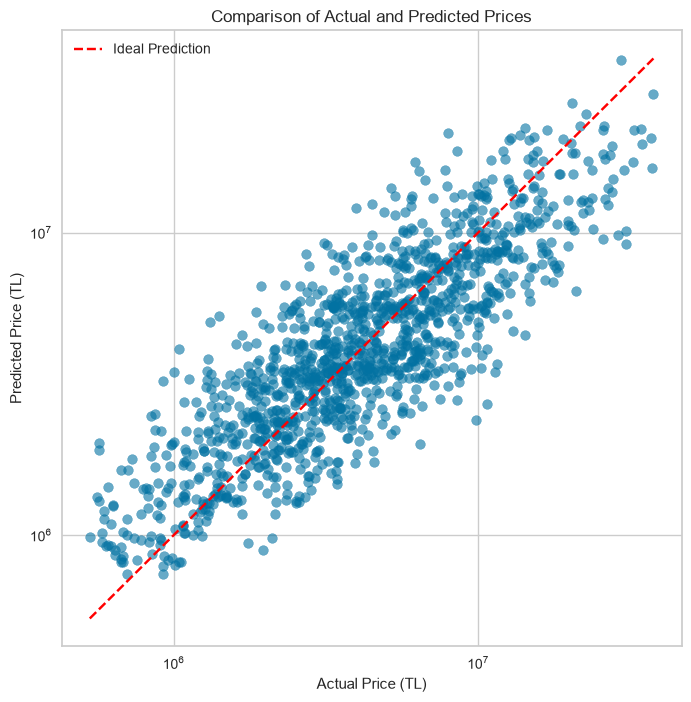

In [172]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

plt.scatter(
    comparison["Actual Price"],
    comparison["Predicted Price"],
    alpha=0.6
)

min_value = min(
    comparison["Actual Price"].min(),
    comparison["Predicted Price"].min()
)
max_value = max(
    comparison["Actual Price"].max(),
    comparison["Predicted Price"].max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    color="red",
    linestyle="--",
    label="Ideal Prediction"
)

plt.xlabel("Actual Price (TL)")
plt.ylabel("Predicted Price (TL)")
plt.title("Comparison of Actual and Predicted Prices")

plt.xscale("log")
plt.yscale("log")

plt.legend()
plt.show()

## 7.9 XGBoost Feature Importance Analysis

The feature importance scores of the optimized XGBoost model were analyzed to identify the variables that contributed most to the prediction of property prices. This analysis provides insight into the model's decision-making process and highlights the most influential features used during prediction.

In [173]:
booster = final_model.get_booster()

gain_scores = booster.get_score(
    importance_type="gain"
)

split_scores = booster.get_score(
    importance_type="weight"
)

gain_importance = pd.DataFrame(
    gain_scores.items(),
    columns=["Feature", "Gain"]
)

split_importance = pd.DataFrame(
    split_scores.items(),
    columns=["Feature", "Split"]
)

importance_comparison = (
    pd.DataFrame({"Feature": X_train.columns})
    .merge(gain_importance, on="Feature", how="left")
    .merge(split_importance, on="Feature", how="left")
    .fillna(0)
)

importance_comparison.sort_values(
    "Gain",
    ascending=False
).head(20)

,Feature,Gain,Split
5,sqm,46.430523,560.0
1,cityId,6.579081,664.0
33,age_group_16-30,0.811626,8.0
7,floorCount,0.776752,72.0
10,heatingId,0.752172,126.0
6,room,0.746056,79.0
30,fuelName_Merkezi,0.710036,9.0
0,subCategoryName,0.707313,66.0
4,age,0.703872,91.0
2,countyId,0.684079,214.0


In [174]:
importance_comparison.sort_values(
    "Split",
    ascending=False
).head(20)

,Feature,Gain,Split
1,cityId,6.579081,664.0
5,sqm,46.430523,560.0
3,districtId,0.674630,293.0
2,countyId,0.684079,214.0
10,heatingId,0.752172,126.0
4,age,0.703872,91.0
8,buildStateId,0.612238,91.0
6,room,0.746056,79.0
7,floorCount,0.776752,72.0
0,subCategoryName,0.707313,66.0


In [175]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": final_model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(by="Importance", ascending=False)
    .reset_index(drop=True)
)

feature_importance.head(15)

,Feature,Importance
0,sqm,0.693072
1,cityId,0.098206
2,age_group_16-30,0.012115
3,floorCount,0.011595
4,heatingId,0.011228
5,room,0.011136
6,fuelName_Merkezi,0.010599
7,subCategoryName,0.010558
8,age,0.010507
9,countyId,0.010211


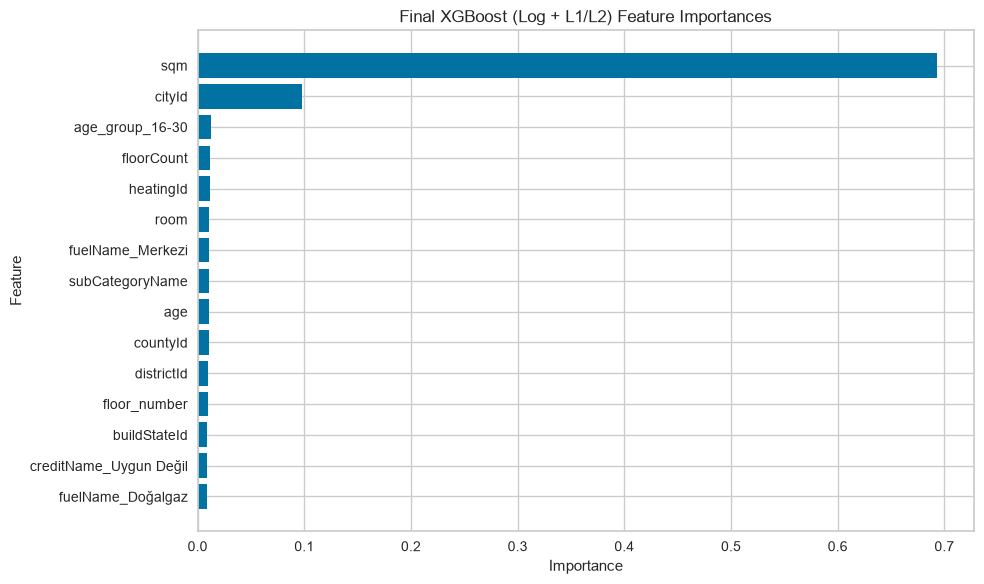

In [176]:
import matplotlib.pyplot as plt


top_features = (
    feature_importance
    .head(15)
    .sort_values(by="Importance", ascending=True)
)


plt.figure(figsize=(10, 6))


plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)


plt.title("Final XGBoost (Log + L1/L2) Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")


plt.tight_layout()


plt.show()

## 8. Model Comparison and Diagnostic Plots


### 8.1 Model Comparison by MAPE

The following graph compares the validation MAPE values of the trained models. Lower MAPE values indicate better relative prediction performance.

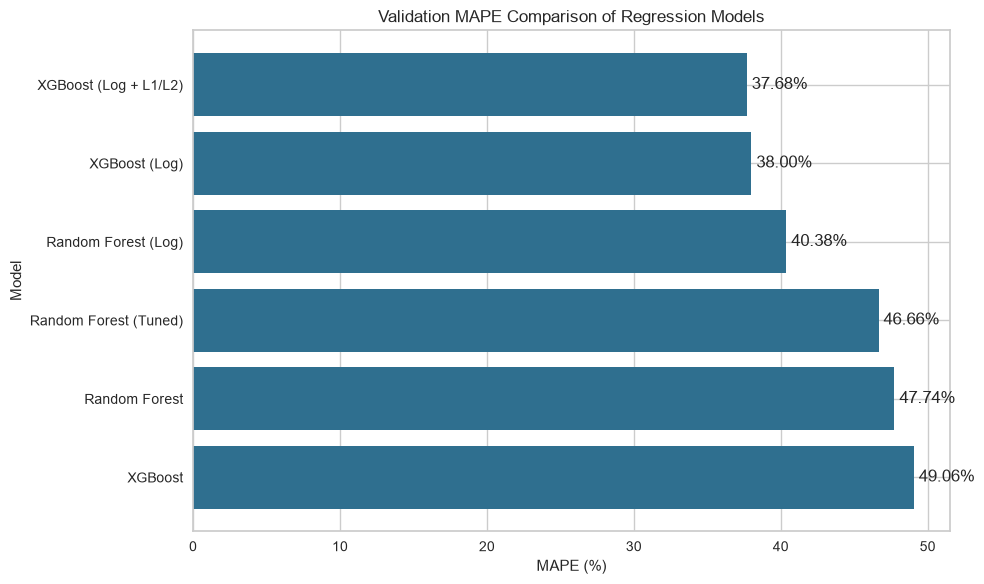

In [177]:
model_comparison_plot = model_comparison.sort_values("MAPE (%)", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(
    model_comparison_plot["Model"],
    model_comparison_plot["MAPE (%)"],
    color="#2f6f8f"
)

plt.xlabel("MAPE (%)")
plt.ylabel("Model")
plt.title("Validation MAPE Comparison of Regression Models")
plt.gca().invert_yaxis()

for index, value in enumerate(model_comparison_plot["MAPE (%)"]):
    plt.text(value, index, f" {value:.2f}%", va="center")

plt.tight_layout()
plt.show()

### 8.2 Validation and Holdout Performance Comparison

This graph compares the final model performance on the validation and holdout datasets. Similar values indicate that the model generalizes consistently to unseen data.

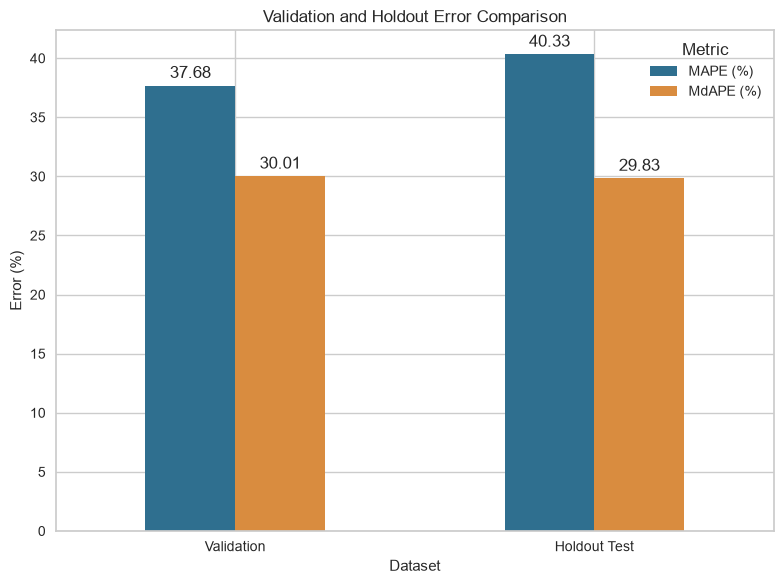

In [178]:
benchmark_plot = benchmark.set_index("Benchmark")[["MAPE (%)", "MdAPE (%)"]]

ax = benchmark_plot.plot(
    kind="bar",
    figsize=(8, 6),
    color=["#2f6f8f", "#d98c3f"]
)

ax.set_xlabel("Dataset")
ax.set_ylabel("Error (%)")
ax.set_title("Validation and Holdout Error Comparison")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title="Metric")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

plt.tight_layout()
plt.show()

### 8.3 Error Rates by Property Subcategory

The following graph shows the mean percentage error for subcategories with at least ten listings in the holdout set. This restriction makes the comparison more reliable.

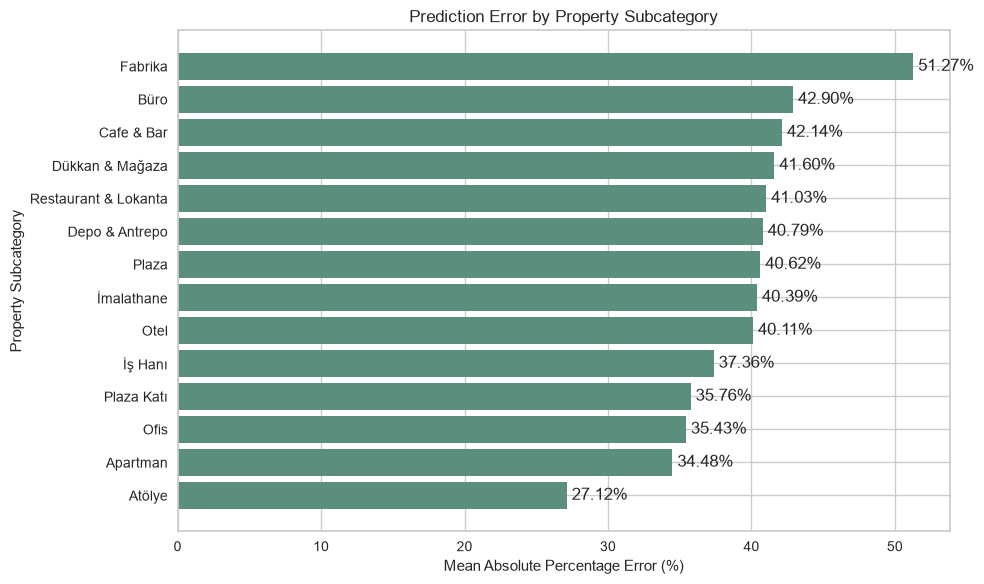

In [179]:
subcategory_plot = subcategory_error_summary.sort_values(
    "MAPE (%)",
    ascending=True
)

plt.figure(figsize=(10, 6))
plt.barh(
    subcategory_plot["subCategoryName"],
    subcategory_plot["MAPE (%)"],
    color="#5b8e7d"
)

plt.xlabel("Mean Absolute Percentage Error (%)")
plt.ylabel("Property Subcategory")
plt.title("Prediction Error by Property Subcategory")

for index, value in enumerate(subcategory_plot["MAPE (%)"]):
    plt.text(value, index, f" {value:.2f}%", va="center")

plt.tight_layout()
plt.show()

## Final Project Summary

This project demonstrates a complete machine learning workflow for commercial real estate price prediction using a synthetic dataset that reflects realistic listing behavior without exposing proprietary or confidential company information. The workflow includes exploratory analysis, data cleaning, missing-value handling, feature engineering, model comparison, and validation.

The notebook evaluates several regression approaches, including tree-based models and regularized boosting methods, to estimate property prices from structured listing attributes. Feature engineering is used to encode location, building quality, floor characteristics, and a synthetic market proxy derived from local pricing patterns.

The final model is selected based on validation performance and error analysis, with emphasis on stability and practical usability. This makes the project suitable as a public-facing portfolio example of how to approach tabular property valuation in a realistic but privacy-safe manner.

In summary, the project combines data science rigor with a clean public-facing presentation, making it a strong example for GitHub sharing and technical discussion.
